# Tutorial 4: ADMET Property Prediction and Toxicity Profiling of CDK2 Inhibitors
## A Comprehensive Cheminformatics Tutorial Using ADMET-AI 2.0 and RDKit

**Authors:** Jane O. Anebi, Festus O. Ogungbemiro & Felix O. Okunlola  
**Institution:** CBIOS - Research Center for Biosciences & Health Technologies, Universidade Lusofona, Lisboa, Portugal and Department of Biochemistry and Biotechnology, Nile University of Nigeria, FCT Abuja, Nigeria  
**Correspondence:** janeanebi@bsum.edu.ng  

---

### Tutorial Overview
This self-contained tutorial provides a complete, reproducible pipeline for ADMET (Absorption, Distribution, Metabolism, Excretion, and Toxicity) property prediction and toxicity profiling of CDK2 inhibitors using ADMET-AI 2.0 and RDKit. Approximately 40% of drug candidates fail in clinical trials due to ADMET liabilities [Waring MJ et al. (2015) Nat Rev Drug Discov 14(7):475-486], making early computational ADMET profiling essential in modern drug discovery.

### ADMET-AI 2.0 - 104 Properties Per Compound
ADMET-AI 2.0 [Swanson K et al. (2024) Bioinformatics 40(7):btae416] predicts 52 ADMET endpoints plus 52 DrugBank approved drug percentile rankings (comparison against 2,579 FDA-approved drugs).

### Learning Objectives
By completing this tutorial, users will be able to:
1. Understand ADMET fundamentals from first principles with clinical context
2. Apply Python and RDKit for molecular representation and descriptor calculation
3. Run ADMET-AI predictions programmatically on a curated compound library
4. Profile all five ADMET domains: Absorption, Distribution, Metabolism, Excretion, Toxicity
5. Interpret Tox21 nuclear receptor and stress response pathway data
6. Use DrugBank percentile rankings to contextualise predictions vs approved drugs
7. Build an ADMET traffic light dashboard and composite ADMET score
8. Export a publication-ready integrated ADMET report

### Required Packages
```
rdkit >= 2024.x    conda install -c conda-forge rdkit
admet-ai >= 2.0    pip install admet-ai
pandas >= 1.5      pip install pandas
numpy >= 1.23      pip install numpy
matplotlib >= 3.5  pip install matplotlib
seaborn >= 0.12    pip install seaborn
scikit-learn >= 1.0 pip install scikit-learn
```

### Dataset
200 CDK2 inhibitors from ChEMBL release 35 (CHEMBL301), stratified by IC50:
25 very potent (<10 nM) + 55 potent (10-100 nM) + 60 moderate (100-1000 nM) + 40 weak (1-10 uM) + 20 inactive (>10 uM)

## Cell 0 - Environment Setup and Version Validation

This cell imports all required libraries, suppresses non-critical warnings from PyTorch Lightning,
validates software versions, and configures global plotting parameters. Always run this cell first.

ADMET-AI uses PyTorch Lightning for model inference. On CPU-only machines, Lightning generates
informational messages about GPU availability that are scientifically irrelevant but visually
clutter output. We suppress these using Python's warnings and logging modules.

**Reference:** Swanson K et al. (2024) ADMET-AI: a machine learning ADMET platform for
evaluation of large-scale chemical libraries. Bioinformatics 40(7):btae416. doi:10.1093/bioinformatics/btae416

In [1]:
# ============================================================
# CELL 0 - Environment setup, version validation, warning suppression
# ============================================================
import sys, os, math, warnings, logging

# Suppress Lightning/PyTorch non-critical messages
warnings.filterwarnings('ignore')
logging.getLogger('lightning').setLevel(logging.ERROR)
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
logging.getLogger('lightning.pytorch').setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# RDKit 2025 correct import paths
from rdkit import Chem, rdBase
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold

import admet_ai
from admet_ai import ADMETModel

print('=' * 65)
print('  TUTORIAL 4: ADMET PROPERTY PREDICTION AND TOXICITY PROFILING')
print('  CDK2 Inhibitor ADMET Analysis | ADMET-AI 2.0 + RDKit')
print('=' * 65)
print(f'  Python    : {sys.version[:10]}')
print(f'  RDKit     : {rdBase.rdkitVersion}')
print(f'  ADMET-AI  : {admet_ai.__version__}')
print(f'  pandas    : {pd.__version__}')
print(f'  numpy     : {np.__version__}')
print(f'  matplotlib: {plt.matplotlib.__version__}')
print(f'  seaborn   : {sns.__version__}')
print('=' * 65)

assert pd.__version__ >= '1.5',  'pandas >= 1.5 required'
assert sns.__version__ >= '0.12','seaborn >= 0.12 required'
print('[OK] All version assertions passed.')

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi':'120','savefig.dpi':'150',
    'font.size':'10','axes.titlesize':'12',
    'axes.labelsize':'10','axes.titleweight':'bold',
})

PALETTE = {
    'safe'    : '#2E7D32',
    'moderate': '#F57F17',
    'risk'    : '#C62828',
    'neutral' : '#1565C0',
    'drugbank': '#6A1B9A',
}
print('[OK] Environment ready for ADMET analysis.')

  TUTORIAL 4: ADMET PROPERTY PREDICTION AND TOXICITY PROFILING
  CDK2 Inhibitor ADMET Analysis | ADMET-AI 2.0 + RDKit
  Python    : 3.11.15 | 
  RDKit     : 2026.03.2
  ADMET-AI  : 2.0.1
  pandas    : 3.0.3
  numpy     : 2.4.6
  matplotlib: 3.10.9
  seaborn   : 0.13.2
[OK] All version assertions passed.
[OK] Environment ready for ADMET analysis.


## Cell 0B - Python and Cheminformatics Fundamentals for ADMET Analysis

This cell introduces the foundational concepts needed to understand every subsequent cell.
Students new to cheminformatics should read all outputs carefully before proceeding.

### SMILES Notation
SMILES (Simplified Molecular Input Line Entry System) is the universal text-based language
for representing chemical structures [Weininger D (1988) J Chem Inf Comput Sci 28(1):31-36].

### What is ADMET?
| Letter | Domain | Key Question |
|--------|--------|-------------|
| A | Absorption | Does it enter the bloodstream? |
| D | Distribution | Does it reach the target tissue? |
| M | Metabolism | How is it chemically modified? |
| E | Excretion | How is it eliminated? |
| T | Toxicity | Does it cause harm? |

**References:**
- Weininger D (1988) SMILES. J Chem Inf Comput Sci 28(1):31-36. doi:10.1021/ci00057a005
- Lipinski CA et al. (1997) Adv Drug Deliv Rev 23(1-3):3-25. doi:10.1016/S0169-409X(96)00423-1
- Waring MJ et al. (2015) Nat Rev Drug Discov 14(7):475-486. doi:10.1038/nrd4609
- Swanson K et al. (2024) Bioinformatics 40(7):btae416. doi:10.1093/bioinformatics/btae416

In [2]:
# ============================================================
# CELL 0B - Python and cheminformatics fundamentals
# ============================================================
print('PART 1: Python Data Structures for Chemistry')
print('=' * 55)
drug_smiles = [
    'CC(=O)Oc1ccccc1C(=O)O',      # Aspirin
    'CC(C)Cc1ccc(C(C)C(=O)O)cc1', # Ibuprofen
    'Cn1cnc2c1c(=O)n(C)c(=O)n2C', # Caffeine
]
drug_names = ['Aspirin', 'Ibuprofen', 'Caffeine']
drug_dict  = dict(zip(drug_names, drug_smiles))
demo_df    = pd.DataFrame({'name': drug_names, 'smiles': drug_smiles})
print(f'List length: {len(drug_smiles)} | Dict keys: {list(drug_dict.keys())}')
print(f'DataFrame shape: {demo_df.shape}')
print(demo_df.to_string(index=False))

print('\n' + '='*55)
print('PART 2: SMILES Parsing and RDKit Molecular Graphs')
print('='*55)
# Reference: Landrum G (2006) RDKit: open-source cheminformatics
for name, smi in drug_dict.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        print(f'\n  {name}:')
        print(f'    Input SMILES     : {smi}')
        print(f'    Canonical SMILES : {Chem.MolToSmiles(mol)}')
        print(f'    MW={Descriptors.MolWt(mol):.1f} Da | '
              f'HAC={mol.GetNumHeavyAtoms()} | '
              f'Rings={Descriptors.RingCount(mol)}')

print('\n' + '='*55)
print('PART 3: The Five ADMET Domains')
print('='*55)
admet_info = [
    ('A - Absorption','Does it reach systemic circulation after oral dosing?',
     'Caco-2, HIA, PAMPA, Pgp substrate, Bioavailability'),
    ('D - Distribution','How does it distribute to tissues and organs?',
     'BBB penetration, Plasma protein binding (PPBR), VDss'),
    ('M - Metabolism','How is it chemically modified in the liver?',
     'CYP1A2/2C9/2C19/2D6/3A4 substrate and inhibitor (7 endpoints)'),
    ('E - Excretion','How is it and its metabolites eliminated?',
     'Hepatocyte clearance, Microsome clearance, Half-life'),
    ('T - Toxicity','Does it or its metabolites cause harmful effects?',
     'hERG, AMES, DILI, ClinTox, LD50, Carcinogens, Tox21 (12 endpoints)'),
]
for domain, question, tools in admet_info:
    print(f'\n  {domain}')
    print(f'    Question : {question}')
    print(f'    Endpoints: {tools}')

print('\n' + '='*55)
print('PART 4: ADMET-AI 2.0 Overview')
print('='*55)
print(f'  Version         : {admet_ai.__version__}')
print( '  Architecture    : Chemprop-RDKit graph neural network')
print( '  Training data   : Therapeutics Data Commons (TDC) benchmark')
print( '  Raw predictions : 52 ADMET endpoints')
print( '  Percentile cols : 52 DrugBank approved drug percentile rankings')
print( '  Total columns   : 104 per compound')
print( '  Reference       : Swanson K et al. (2024) Bioinformatics 40(7):btae416')
print('\n[OK] Fundamentals complete.')

PART 1: Python Data Structures for Chemistry
List length: 3 | Dict keys: ['Aspirin', 'Ibuprofen', 'Caffeine']
DataFrame shape: (3, 2)
     name                     smiles
  Aspirin      CC(=O)Oc1ccccc1C(=O)O
Ibuprofen CC(C)Cc1ccc(C(C)C(=O)O)cc1
 Caffeine Cn1cnc2c1c(=O)n(C)c(=O)n2C

PART 2: SMILES Parsing and RDKit Molecular Graphs

  Aspirin:
    Input SMILES     : CC(=O)Oc1ccccc1C(=O)O
    Canonical SMILES : CC(=O)Oc1ccccc1C(=O)O
    MW=180.2 Da | HAC=13 | Rings=1

  Ibuprofen:
    Input SMILES     : CC(C)Cc1ccc(C(C)C(=O)O)cc1
    Canonical SMILES : CC(C)Cc1ccc(C(C)C(=O)O)cc1
    MW=206.3 Da | HAC=15 | Rings=1

  Caffeine:
    Input SMILES     : Cn1cnc2c1c(=O)n(C)c(=O)n2C
    Canonical SMILES : Cn1c(=O)c2c(ncn2C)n(C)c1=O
    MW=194.2 Da | HAC=14 | Rings=2

PART 3: The Five ADMET Domains

  A - Absorption
    Question : Does it reach systemic circulation after oral dosing?
    Endpoints: Caco-2, HIA, PAMPA, Pgp substrate, Bioavailability

  D - Distribution
    Question : How does it d

## Cell 1 - Standalone CDK2 Inhibitor Dataset Construction

This cell constructs a self-contained dataset of 200 CDK2 inhibitors for ADMET analysis.
The dataset is embedded directly and requires no external files.

### About CDK2
CDK2 (UniProt P24941, ChEMBL ID: CHEMBL301) is a serine/threonine kinase essential for
cell cycle regulation. CDK2 forms complexes with Cyclin E (G1/S transition) and Cyclin A
(S phase), making it a validated oncology target [Malumbres M & Barbacid M (2009)
Nat Rev Cancer 9(3):153-166. doi:10.1038/nrc2602].

### Curation Strategy
All compounds were retrieved from ChEMBL release 35 [Mendez D et al. (2019) Nucleic Acids
Res 47(D1):D930-D939] using a six-step curation pipeline including geometric mean
aggregation of replicate IC50 measurements [Landrum G & Riniker S (2024) J Chem Inf Model
64(5):1560-1567. doi:10.1021/acs.jcim.4c00049].

### Stratified Selection
| Stratum | IC50 Range | Count |
|---------|-----------|-------|
| Very potent | < 10 nM | 25 |
| Potent | 10-100 nM | 55 |
| Moderate | 100-1000 nM | 60 |
| Weak | 1-10 uM | 40 |
| Inactive | > 10 uM | 20 |

In [3]:
# ============================================================
# CELL 1 - Standalone CDK2 inhibitor dataset (200 compounds)
# Source: ChEMBL release 35, target CHEMBL301 (CDK2, Homo sapiens)
# Curation: six-step pipeline + geometric mean aggregation
# Reference: Mendez D et al. (2019) Nucleic Acids Res 47(D1):D930-D939
# Reference: Landrum G & Riniker S (2024) J Chem Inf Model 64(5):1560-1567
# ============================================================
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

CDK2_DATASET = [
    # (chembl_id, canonical_smiles, IC50_nM_geomean)
    # All values verified from ChEMBL release 35
    ('CHEMBL388978', 'CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3c3c4c(c5c6ccccc6n2c5c31)C(=O)NC4', 0.8698),
    ('CHEMBL2103840', 'CCc1cnn2c(NCc3ccc[n+]([O-])c3)cc(N3CCCC[C@H]3CCO)nc12', 4.7249),
    ('CHEMBL3648110', 'C[C@H](O)[C@@H](C)Nc1nc(Nc2ccc(S(=N)(=O)CCO)cc2)ncc1Br', 5.0133),
    ('CHEMBL102926', 'Cc1nc2ccccn2c1-c1ccnc(Nc2ccc(OCC(O)CN(C)C)cc2)n1', 6.8399),
    ('CHEMBL73303', 'NS(=O)(=O)c1ccc(Nc2nccc(-c3cnc4ccccn34)n2)cc1', 1.4142),
    ('CHEMBL190446', 'C[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2Cc3ccccc3C2=O)cc1', 2.0000),
    ('CHEMBL192602', 'C[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2CCNC2=O)cc1', 2.0000),
    ('CHEMBL1964259', 'O=C1Nc2ccc3ncsc3c2/C1=C/Nc1ccc(S(=O)(=O)NCCOCCO)cc1', 2.5456),
    ('CHEMBL191003', 'Nc1nc(Nc2ccc(S(N)(=O)=O)cc2)nn1C(=O)c1c(F)cccc1F', 2.8284),
    ('CHEMBL490481', 'O=C(Cc1ccc(Cc2cccs2)cc1)Nc1cc(C2CC2)[nH]n1', 2.9995),
    ('CHEMBL3648112', 'COc1cc(Nc2ncc(Br)c(N[C@H](C)[C@H](C)O)n2)ccc1S(C)(=N)=O', 3.4641),
    ('CHEMBL3648115', 'COc1cc(Nc2ncc(Br)c(N[C@H](C)C(C)(C)O)n2)ccc1S(C)(=N)=O', 3.4641),
    ('CHEMBL489477', 'O=C(Cc1ccc(-c2ccccc2)c(F)c1)Nc1cc(C2CC2)[nH]n1', 3.9995),
    ('CHEMBL3639469', 'Cc1cc(Nc2ncc(Br)c(N[C@H](C)C(C)(C)O)n2)ccc1S(C)(=N)=O', 5.2915),
    ('CHEMBL3644033', 'C[C@@H](O)[C@@H](C)Oc1nc(Nc2ccc(S(C)(=O)=O)cc2)ncc1C(F)(F)F', 5.6569),
    ('CHEMBL359554', 'c1ccc(Nc2nccc(-c3cnn4ncccc34)n2)cc1', 6.3321),
    ('CHEMBL4442620', 'C[C@@H](O)[C@@H](C)Oc1nc(Nc2ccc(S(=N)(=O)C3CC3)cc2)ncc1C(F)(F)F', 6.7082),
    ('CHEMBL23254', 'CC(C)[C@H](CO)Nc1nc(Nc2ccc(C(=O)O)c(Cl)c2)c2ncn(C(C)C)c2n1', 7.3485),
    ('CHEMBL3642650', 'Clc1ccccc1-c1cc(NCc2ccncc2)n2ncc(Br)c2n1', 7.7460),
    ('CHEMBL3648128', 'CC(C)(O)CSc1nc(Nc2ccc(S(C)(=N)=O)cc2)ncc1Br', 8.0000),
    ('CHEMBL490480', 'Cc1cc(CC(=O)Nc2cc(C3CC3)[nH]n2)ccc1-c1ccccc1', 8.9975),
    ('CHEMBL3644032', 'C[C@@H](O)[C@@H](C)Oc1nc(Nc2ccc(S(=O)(=O)C3CC3)cc2)ncc1C(F)(F)F', 9.7980),
    ('CHEMBL3644034', 'C[C@@H](Oc1nc(Nc2ccc(S(C)(=O)=O)cc2)ncc1C(F)(F)F)C(C)(C)O', 9.7980),
    ('CHEMBL526110', 'O=[N+]([O-])c1cccc(Nc2nccc(-c3cnn4ncccc34)n2)c1', 0.3000),
    ('CHEMBL317703', 'NS(=O)(=O)c1ccc(Nc2cc(-c3ccc([N+](=O)[O-])cc3)[nH]n2)cc1', 0.3300),
    ('CHEMBL296468', 'CC(C)(C)c1cnc(CSc2cnc(NC(=O)C3CCNCC3)s2)o1', 87.3358),
    ('CHEMBL428690', 'CN1CC[C@H](c2c(O)cc(O)c3c(=O)cc(-c4ccccc4Cl)oc23)[C@H](O)C1', 58.0029),
    ('CHEMBL1944698', 'CN1C/C=C/CCOc2cccc(c2)-c2ccnc(n2)Nc2cccc(c2)C1', 12.6181),
    ('CHEMBL3655762', 'CC[C@H](Nc1nc(NCc2cnc(C)cc2C)c2ncn(C(C)C)c2n1)[C@@H](C)O', 14.1861),
    ('CHEMBL3919361', 'O=C1NCC2(CCCCC2)n2c1cc1cnc(Nc3ccc(N4CCC(N5CCOCC5)CC4)cn3)nc12', 35.3726),
    ('CHEMBL3894860', 'CN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC1', 52.6517),
    ('CHEMBL3890528', 'O=C1NCC2(CCCCC2)n2c1cc1cnc(Nc3ccc(N4CCNCC4)cn3)nc12', 57.2049),
    ('CHEMBL3904602', 'CC(C)N1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC1', 73.5241),
    ('CHEMBL23327', 'CC(C)[C@H](CO)Nc1nc(Nc2cccc(Cl)c2)c2ncn(C(C)C)c2n1', 21.3997),
    ('CHEMBL5755607', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)CCN(CCN=C(N)N)C5)ncc3F)cc2n1C(C)C', 57.9859),
    ('CHEMBL3648123', 'CCS(=N)(=O)c1ccc(Nc2ncc(Br)c(N[C@H](C)C(C)(C)O)n2)cc1', 11.6190),
    ('CHEMBL192042', 'C[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2CCN(C)C2=O)cc1', 16.9900),
    ('CHEMBL5950534', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)C[C@@H](C)NC5)ncc3F)cc2n1C(C)(C)C', 18.5429),
    ('CHEMBL191834', 'C[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2CCOC2=O)cc1', 20.0000),
    ('CHEMBL5971879', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)CCN[C@H]5C)ncc3F)cc2n1C(C)(C)C', 21.2356),
    ('CHEMBL445813', 'O=C(NC1CCNCC1)c1n[nH]cc1NC(=O)c1c(Cl)cccc1Cl', 21.6795),
    ('CHEMBL401377', 'Brc1cnn2c(NCc3ccncc3)cc(-c3ccccc3)nc12', 24.0832),
    ('CHEMBL6031262', 'C/C(=N/O)N(C)CCN1CCc2nc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)ccc2C1', 24.5561),
    ('CHEMBL3642646', 'Fc1ccccc1-c1cc(NCc2ccncc2)n2ncc(Br)c2n1', 27.7128),
    ('CHEMBL114917', 'COc1cccc(CC(=O)Nc2cc(C3CC3)[nH]n2)c1', 28.9850),
    ('CHEMBL5814867', 'CNCC(=O)N1CCc2nc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)ccc2C1', 29.1465),
    ('CHEMBL3655764', 'CC[C@H](Nc1nc(NCc2cccc(Cl)c2)c2ncn(C(C)C)c2n1)[C@@H](C)O', 31.6228),
    ('CHEMBL5982253', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)C[C@@H](C)N(CCN(C)C)C5)ncc3F)cc2n1C(C)(C)C', 32.5521),
    ('CHEMBL115319', 'O=C(Nc1cc(C2CC2)[nH]n1)c1ccc(Br)cc1', 33.9800),
    ('CHEMBL270054', 'NS(=O)(=O)c1ccc(N/N=C2\C(=O)Nc3ccc(Cl)cc32)cc1', 35.9166),
    ('CHEMBL191144', 'C[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2CCCC2=O)cc1', 36.9900),
    ('CHEMBL5574741', 'Cn1cnc(S(=O)(=O)N2CCC(Nc3ncc(C#N)c(-c4cnn(CC(F)(F)F)c4)n3)CC2)c1', 40.1248),
    ('CHEMBL3642649', 'Fc1ccccc1-c1cc(NCc2ccncc2)n2ncc(Cl)c2n1', 43.0813),
    ('CHEMBL6013826', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)CCN(CCN(C)C)[C@H]5C)ncc3F)cc2n1C(C)(C)C', 44.5257),
    ('CHEMBL5562769', 'CNCc1ccc(-n2cc(-c3nc(NC4CCN(S(C)(=O)=O)CC4)ncc3C#N)cn2)c(Cl)c1', 44.8999),
    ('CHEMBL114851', 'O=C(Cc1ccccc1)Nc1cc(C2CC2)[nH]n1', 47.9850),
    ('CHEMBL5591731', 'N#Cc1cnc(NC2CCN(S(=O)(=O)c3ccccn3)CC2)nc1-c1cnn(CC(F)(F)F)c1', 48.3529),
    ('CHEMBL3655765', 'CC[C@H](Nc1nc(NCc2cccc(F)c2)c2ncn(C(C)C)c2n1)[C@@H](C)O', 48.9898),
    ('CHEMBL419753', 'O=C(Nc1cc(C2CCCC2)[nH]n1)c1ccc(Br)cc1', 50.0000),
    ('CHEMBL1080569', 'N[C@H](CNc1nnc(-c2ccc3cnccc3c2)s1)Cc1ccc(C(F)(F)F)cc1', 51.4782),
    ('CHEMBL5583697', 'Cn1cnc(S(=O)(=O)N2CCC(Nc3ncc(C(F)(F)F)c(-c4cnn(CC(F)(F)F)c4)n3)CC2)c1', 53.2823),
    ('CHEMBL115933', 'O=C(Cc1ccc(-c2ccccc2)cc1)Nc1cc(C2CC2)[nH]n1', 55.9900),
    ('CHEMBL1922219', 'CC[C@H](Nc1nc(NCc2cccnc2)c2ncn(C(C)C)c2n1)[C@@H](C)O', 57.4456),
    ('CHEMBL5592661', 'CS(=O)(=O)N1CCC(Nc2ncc(C(F)(F)F)c(-c3cnn(-c4ccc(C#N)cc4Cl)c3)n2)CC1', 64.6993),
    ('CHEMBL115994', 'O=C(Cc1ccc(OC(F)(F)F)cc1)Nc1cc(C2CC2)[nH]n1', 66.9950),
    ('CHEMBL325606', 'NC(=O)c1ccc(C(=O)Nc2cc(C3CC3)[nH]n2)cc1', 68.0400),
    ('CHEMBL324577', 'NC(=O)c1ccc(CC(=O)Nc2cc(C3CC3)[nH]n2)cc1', 73.9800),
    ('CHEMBL365341', 'C[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2CCCC2)cc1', 79.9900),
    ('CHEMBL5573043', 'CNCc1ccc(-n2cc(-c3nc(NC4CCN(S(C)(=O)=O)CC4)ncc3C(F)(F)F)cn2)c(Cl)c1', 81.0864),
    ('CHEMBL323392', 'O=C(Nc1cc(C2CC2)[nH]n1)c1ccc(Cl)c(Cl)c1', 82.9950),
    ('CHEMBL366230', 'C[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccccc1', 83.9750),
    ('CHEMBL5569715', 'CC(C)(O)Cn1cc(-c2nc(NC3CCN(S(=O)(=O)C4CC4)CC3)ncc2C(F)(F)F)cn1', 84.6404),
    ('CHEMBL115264', 'O=C(Nc1cc(C2CC2)[nH]n1)c1ccc(Cl)cc1', 84.9600),
    ('CHEMBL72461', 'Cc1nc2ccccn2c1-c1ccnc(Nc2ccccc2)n1', 86.9483),
    ('CHEMBL3967592', 'O=C1NCC2(CCCCC2)n2c1cc1cnc(Nc3ccc(C(=O)N4CCNCC4)cn3)nc12', 86.9713),
    ('CHEMBL5556607', 'CC(C)(O)Cn1cc(-c2nc(NC3CCN(S(=O)(=O)C4CC4)CC3)ncc2C#N)cn1', 87.1321),
    ('CHEMBL112136', 'O=C(Nc1cc(C2CCC2)[nH]n1)c1ccc(Br)cc1', 89.9750),
    ('CHEMBL5836990', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)CCNC5)ncc3F)cc2n1C(C)C', 97.3961),
    ('CHEMBL1171948', 'NC(=O)Cn1nc(C(N)=O)c2c1-c1nc(Nc3ccccc3)ncc1CC2', 10.0000),
    ('CHEMBL178785', 'CN(C)S(=O)(=O)c1ccc(Nc2cc(N[C@H]3CC[C@H](N)CC3)nc3c(Br)cnn23)cc1', 10.0000),
    ('CHEMBL319467', 'NS(=O)(=O)c1ccc(Nc2nc(OCC3CCCCC3)c3nc[nH]c3n2)cc1', 112.798),
    ('CHEMBL258805', 'COc1ccc2c(c1)/C(=C/c1cnc[nH]1)C(=O)N2', 214.514),
    ('CHEMBL5589612', 'CO[C@@]1(C)[C@H](O)C(=O)C(C)=C2OC(=O)c3c(C)cc(O)c(C)c3O[C@@H]21', 904.324),
    ('CHEMBL3946675', 'COc1cc(F)ccc1-c1nc(Nc2cc(Br)cc(CS(C)(=N)=O)c2)ncc1F', 104.318),
    ('CHEMBL3301610', 'CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C)C)c5c4)n3)nc2)CC1', 169.709),
    ('CHEMBL3960677', 'COc1cc(CS(C)(=N)=O)cc(Nc2ncc(F)c(-c3ccc(F)cc3OC)n2)c1', 181.561),
    ('CHEMBL3897217', 'COc1cc(F)ccc1-c1nc(Nc2cc(F)c(F)c(CS(C)(=N)=O)c2)ncc1F', 185.915),
    ('CHEMBL3917892', 'CCS(=N)(=O)Cc1cc(F)cc(Nc2ncc(F)c(-c3ccc(F)cc3OC)n2)c1', 251.721),
    ('CHEMBL3962241', 'COc1cc(F)ccc1-c1nc(Nc2cc(F)cc(CS(C)(=N)=O)c2)ncc1F', 279.455),
    ('CHEMBL3959867', 'CCOc1cc(F)ccc1-c1nc(Nc2cc(F)cc(CS(C)(=N)=O)c2)ncc1F', 316.897),
    ('CHEMBL3960348', 'COc1cc(F)ccc1-c1nc(Nc2cccc(CS(C)(=O)=NC#N)c2)ncc1F', 356.068),
    ('CHEMBL3976450', 'CCS(=N)(=O)Cc1cccc(Nc2ncc(F)c(-c3ccc(F)cc3OC)n2)c1', 379.209),
    ('CHEMBL3934257', 'COc1cc(F)ccc1-c1nc(Nc2cc(F)cc(CS(=N)(=O)C3CC3)c2)ncc1F', 448.744),
    ('CHEMBL3927078', 'CS(=N)(=O)Cc1cccc(Nc2ncc(F)c(-c3ccc(F)cc3OCc3ccccc3)n2)c1', 485.221),
    ('CHEMBL3965161', 'COc1cc(F)ccc1-c1nc(Nc2cccc(CS(C)(=N)=O)c2)ncc1F', 653.574),
    ('CHEMBL4781539', 'C=CC(=O)Nc1ccc(C(=O)N2CCCC(Nc3ncc(SCc4ncc(C(C)(C)C)o4)s3)C2)cc1', 113.842),
    ('CHEMBL6064669', 'CCN1CCC(c2ccc(Nc3ncc(F)c(-c4cc(F)c5nc6n(c5c4)C(C)(C)CC6)n3)nc2)CC1', 116.962),
    ('CHEMBL3972676', 'CN1CCN(C(=O)c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCC3)CNC5=O)nc2)CC1', 126.075),
    ('CHEMBL564829', 'CNC(=O)c1nn(C)c2c1C(C)(C)Cc1cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc1-2', 127.808),
    ('CHEMBL4303287', 'CN(C)C/C=C/C(=O)Nc1cccc(C(=O)Nc2cccc(Nc3ncc(Cl)c(-c4c[nH]c5ccccc45)n3)c2)c1', 146.669),
    ('CHEMBL3895782', 'O=C1NCC2(CCCCC2)n2c1cc1cnc(Nc3ccc(C(=O)N4CCN(C5CCC5)CC4)cn3)nc12', 147.702),
    ('CHEMBL5570663', 'Cn1cc(S(=O)(=O)N2CCC(Nc3ncc(C(F)(F)F)c(-c4cnn(CC(F)(F)F)c4)n3)CC2)cn1', 154.871),
    ('CHEMBL3955818', 'CC(C)(C)CCN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCC3)CNC5=O)nc2)CC1', 159.387),
    ('CHEMBL324186', 'O=C(O)c1ccc(C(=O)Nc2cc(C3CC3)[nH]n2)cc1', 164.910),
    ('CHEMBL192126', 'C[C@@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2Cc3ccccc3C2=O)cc1', 169.910),
    ('CHEMBL336242', 'O=C(Nc1cc(CN[C@H]2Cc3ccc(Cl)cc3C2)n[nH]1)Nc1cccc2c1[C@@H]1CCCN1C2=O', 185.257),
    ('CHEMBL141247', 'O=C(Nc1ccccn1)Nc1cccc2c1[C@H]1CCCN1C2=O', 187.617),
    ('CHEMBL5186159', 'NS(=O)(=O)c1ccc(Nc2ncc3c(n2)N(C2CCCC2)C(=O)C32CC2)cc1', 192.977),
    ('CHEMBL430703', 'CC(C)c1cc(NC(=O)c2ccc(Br)cc2)n[nH]1', 199.995),
    ('CHEMBL112442', 'CCCC(=O)Nc1cc(C2CC2)[nH]n1', 223.935),
    ('CHEMBL6033665', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)CCNC5)ncc3F)cc2n1C', 247.459),
    ('CHEMBL133342', 'CC[C@@H](CO)Nc1nc(NCc2ccccc2)c2ncn(C(C)C)c2n1', 264.575),
    ('CHEMBL3942483', 'O=C1NCC2(CCCC2)n2c1cc1cnc(Nc3ccc(C(=O)N4CCN(CC5CC5)CC4)cn3)nc12', 282.452),
    ('CHEMBL324942', 'O=C(Nc1cc(C2CC2)n[nH]1)c1ccccc1', 289.865),
    ('CHEMBL3913590', 'CC(C)N1CCN(C(=O)c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC1', 296.164),
    ('CHEMBL3967732', 'O=C1NCC2(CCCCC2)n2c1cc1cnc(Nc3ccc(N4CCN(C5CCC5)CC4)cn3)nc12', 345.427),
    ('CHEMBL5932825', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)CCN(C(=O)CN(C)C)C5)ncc3F)cc2n1C1CC1', 354.333),
    ('CHEMBL3943554', 'CC(C)C1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1', 376.537),
    ('CHEMBL573578', 'CC(C)(C)n1nc(Cc2cccc3ccccc23)c2c(N)ncnc21', 380.789),
    ('CHEMBL489833', 'Cn1cc(C2=C(c3coc4cc(CO)ccc34)C(=O)NC2=O)c2cc(Br)ccc21', 430.523),
    ('CHEMBL189047', 'C[C@@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2CCNC2=O)cc1', 454.995),
    ('CHEMBL4518287', 'C=CS(=O)(=O)c1ccc(Nc2nc(OCC3CCCCC3)c3nc[nH]c3n2)cc1', 457.821),
    ('CHEMBL5832698', 'Cc1nc2c(F)cc(-c3nc(Nc4ccc5c(n4)CCN(C(=O)[C@@H](C)N(C)C)C5)ncc3F)cc2n1C1CC1', 498.193),
    ('CHEMBL333605', 'O=C(Nc1cc(C2CC2)[nH]n1)c1cccc(C(F)(F)F)c1', 500.015),
    ('CHEMBL264406', 'CC(C)(C)n1nc(-c2cccc3ccccc23)c2c(N)ncnc21', 519.615),
    ('CHEMBL3986852', 'O=C1NCC2(CCCCC2)n2c1cc1cnc(Nc3ccc(N4CCN(CC5CC5)CC4)cn3)nc12', 582.409),
    ('CHEMBL420135', 'COc1cccc(C(=O)Nc2cc(C3CC3)[nH]n2)c1', 599.895),
    ('CHEMBL115047', 'CCc1cc(NC(=O)c2ccc(Br)cc2)n[nH]1', 629.755),
    ('CHEMBL1957085', 'COc1ccc(-c2ocnc2C(=O)NCc2ccncc2)cc1', 630.960),
    ('CHEMBL3673434', 'COc1cc(F)ccc1-c1ccnc(NC(=O)[C@H]2CCC[C@@H](NC(C)=O)C2)c1', 642.869),
    ('CHEMBL114432', 'CCCc1cc(NC(=O)c2ccc(Br)cc2)n[nH]1', 650.065),
    ('CHEMBL4115060', 'C[C@@H](O)CN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC1', 653.835),
    ('CHEMBL4439321', 'COc1cc(F)ccc1-c1ncnc(Nc2cccc(C[S@](C)(=N)=O)c2)n1', 685.565),
    ('CHEMBL111897', 'COc1ccc(C(=O)Nc2cc(C3CC3)[nH]n2)cc1', 704.845),
    ('CHEMBL3956661', 'CC1(C)CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1CC1CC1', 756.994),
    ('CHEMBL3975020', 'CC(C)N1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nn2)CC1', 866.579),
    ('CHEMBL3920205', 'CC1CCN(C2CCN(c3ccc(Nc4ncc5cc6n(c5n4)C4(CCCCC4)CNC6=O)nc3)CC2)C1', 888.628),
    ('CHEMBL3947713', 'CC1(C)CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1C1CC1', 918.346),
    ('CHEMBL193287', 'N[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccccc1', 959.700),
    ('CHEMBL3916385', 'CCN(CC)C1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC1', 971.468),
    ('CHEMBL14762', 'CC[C@H](CO)Nc1nc(NCc2ccccc2)c2ncn(C(C)C)c2n1', 4512.45),
    ('CHEMBL211514', 'Cc1ccc(Cl)c(N(CC#N)c2cc(Nc3ccc(OC[C@@H](O)CN(C)C)cc3)ncn2)c1', 1141.96),
    ('CHEMBL3980597', 'CCC(C)CN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCC3)CNC5=O)nc2)CC1', 2987.15),
    ('CHEMBL3890659', 'CCN(CC)C1CCN(C2CCN(c3ccc(Nc4ncc5cc6n(c5n4)C4(CCCCC4)CNC6=O)nc3)CC2)C1', 1046.39),
    ('CHEMBL3955667', 'C[C@H](O)CN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)C[C@@H]1C', 1087.53),
    ('CHEMBL3918318', 'C[C@H]1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1', 1269.02),
    ('CHEMBL3934575', 'CC1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1CCC(C)(C)C', 1291.00),
    ('CHEMBL3655763', 'CC[C@H](Nc1nc(NCc2ccc(C)nc2)c2ncn(C(C)C)c2n1)[C@@H](C)O', 1300.00),
    ('CHEMBL3891784', 'CC(C)N1CCN(Cc2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC1', 1357.42),
    ('CHEMBL3961115', 'CCOCCN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCC3)CNC5=O)nc2)CC1', 1367.88),
    ('CHEMBL4114182', 'C[C@@H]1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)C[C@H](C)N1C[C@@H](C)O', 1422.61),
    ('CHEMBL3894204', 'CN(C)C1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nn2)CC1', 1424.57),
    ('CHEMBL3897592', 'C[C@@H](O)CN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCC3)CNC5=O)nc2)C[C@@H]1C', 1440.51),
    ('CHEMBL3925377', 'CC1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1CC(C)(C)O', 1462.82),
    ('CHEMBL115125', 'Cc1cc(NC(=O)c2ccccc2)n[nH]1', 1499.84),
    ('CHEMBL116047', 'O=C(Nc1cc(C2CC2)[nH]n1)c1ccccc1Br', 1499.84),
    ('CHEMBL3896827', 'CC1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC(C)N1CC1CC1', 1506.19),
    ('CHEMBL3929122', 'CC1(C)CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1', 1547.77),
    ('CHEMBL3938919', 'C[C@H](O)CN1[C@H](C)CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)C[C@@H]1C', 1549.31),
    ('CHEMBL3901454', 'C[C@H]1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1C', 1615.92),
    ('CHEMBL3896841', 'CC(C)(O)CN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCC3)CNC5=O)nc2)CC1', 1667.89),
    ('CHEMBL3972093', 'CC1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCC3)CNC5=O)nc2)CCN1CC1CC1', 1720.26),
    ('CHEMBL346119', 'O=c1c(O)cc([C@H]2Oc3cc(O)cc(O)c3C[C@H]2O)cc2c([C@H]3Oc4cc(O)cc(O)c4C[C@H]3O)cc(O)c(O)c12', 1788.85),
    ('CHEMBL3981462', 'C[C@H]1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1CCC(C)(C)C', 1792.99),
    ('CHEMBL3701062', 'Cc1nccc(-c2ccc(C(=O)N3CCOCC3)c(Cl)c2)c1C#Cc1ccc(N)nc1', 1816.59),
    ('CHEMBL271673', 'Nc1c(S(=O)(=O)[O-])cc(Nc2ccc(Cl)cc2)c2c1C(=O)c1ccccc1C2=O.[Na+]', 1858.79),
    ('CHEMBL3906916', 'C[C@@H]1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)C[C@H](C)N1', 1896.21),
    ('CHEMBL1257080', 'Cc1nc(/N=N/c2ccc(C(=O)[O-])cc2)c(COP(=O)([O-])[O-])c(C=O)c1O.[Na+].[Na+].[Na+]', 1897.37),
    ('CHEMBL190154', 'CO[C@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccccc1', 1999.93),
    ('CHEMBL3920345', 'O=C1NCC2(CCCC2)n2c1cc1cnc(Nc3ccc(N4CCOCC4)nn3)nc12', 2070.36),
    ('CHEMBL3973056', 'CN1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC1(C)C', 2284.73),
    ('CHEMBL3917699', 'C[C@H]1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1CC1CC1', 2397.00),
    ('CHEMBL192179', 'C[C@@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2CCOC2=O)cc1', 2500.17),
    ('CHEMBL192471', 'C[C@@H](C(=O)Nc1cc(C2CC2)[nH]n1)c1ccc(N2CCCC2=O)cc1', 2500.17),
    ('CHEMBL3975426', 'CCN1[C@H](C)CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)C[C@@H]1C', 2543.23),
    ('CHEMBL4109276', 'CC(C)N1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)C[C@H]1C', 2598.02),
    ('CHEMBL190178', 'O=C(Nc1cc(C2CC2)[nH]n1)C(=O)c1ccccc1', 2600.08),
    ('CHEMBL5404588', 'Cc1ccc(S(=O)(=O)Nc2cc(S(=O)(=O)[O-])c(N)c3c2C(=O)c2ccccc2C3=O)cc1.[Na+]', 2607.30),
    ('CHEMBL4112645', 'C[C@@H]1CN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CCN1C', 2707.77),
    ('CHEMBL3966804', 'CCN(CC)C1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCC3)CNC5=O)nc2)CC1', 2708.99),
    ('CHEMBL3616869', 'CSc1ccc(/C=N/c2cc([N+](=O)[O-])ccc2O)cc1', 61960.3),
    ('CHEMBL522590', 'Cn1cc(C2=C(c3coc4cc(CO)ccc34)C(=O)NC2=O)c2cc(F)c(Cl)cc21', 11136.4),
    ('CHEMBL3943841', 'CN(C)C1CCN(c2ccc(Nc3ncc4cc5n(c4n3)C3(CCCCC3)CNC5=O)nc2)CC1', 11421.1),
    ('CHEMBL366861', 'Cc1cc(O)c(C=O)c2c1C(=O)Oc1c(COC(=O)/C=C/C(=O)O)c(O)c(C(=O)O)c(C)c1O2', 11661.9),
    ('CHEMBL5401470', 'O=C(O)c1ccc([N+](=O)[O-])c2c1NC(c1ccc(Cl)cc1)C1CC=CC21', 12573.8),
    ('CHEMBL1256759', 'O=C(O)c1cc([N+](=O)[O-])ccc1NCCCc1ccccc1', 23323.8),
    ('CHEMBL1332616', 'O=C1OC2(c3ccccc31)c1cc(I)c(O)c(I)c1Oc1c2cc(I)c(O)c1I', 24392.6),
    ('CHEMBL495758', 'c1ccc2[nH]c(-c3cc[nH]n3)nc2c1', 26457.5),
    ('CHEMBL209148', 'COc1cc(C)c(Sc2cnc(NC(=O)c3ccc(CNC(C)C(C)(C)C)cc3)s2)cc1C(=O)N1CCN(C(C)=O)CC1', 29000.0),
    ('CHEMBL102047', 'CN(C)CC(O)COc1ccc(Nc2nccc(Nc3ccccc3)n2)cc1', 32984.8),
    ('CHEMBL5427167', 'Cc1cc(O)c(C(C)C)cc1C1(c2cc(C(C)C)c(O)cc2C)OS(=O)(=O)c2ccccc21', 34481.9),
    ('CHEMBL450786', 'Cc1[nH]c(/C=C2\C(=O)Nc3ccc(S(=O)(=O)Cc4c(Cl)cccc4Cl)cc32)c(C)c1C(=O)N1CCC[C@@H]1CN1CCCC1', 41533.1),
    ('CHEMBL522760', 'COc1cccc2c(C3=C(c4cn(C)c5cc(Cl)c(F)cc45)C(=O)NC3=O)coc12', 51892.2),
    ('CHEMBL12131', 'Cc1cc(C(C#N)c2ccc(Cl)cc2)c(Cl)cc1NC(=O)c1cc(I)cc(I)c1O', 10000.0),
    ('CHEMBL1809195', 'COc1cc(N2CCN(C(C)=O)CC2)ccc1Nc1ncc(C)c(-c2cnc3ccccn23)n1', 10000.0),
    ('CHEMBL217092', 'CN1CCN(CCOc2cc(OC3CCOCC3)c3c(Nc4c(Cl)ccc5c4OCO5)ncnc3c2)CC1', 10000.0),
    ('CHEMBL2348171', 'C#Cc1ccc2ccn(-c3ccnc(N)n3)c2c1', 10000.0),
    ('CHEMBL245725', 'CCNC(=O)N1CCC(Nc2nccc(-c3c[nH]c4ccccc34)n2)CC1', 10000.0),
    ('CHEMBL392613', 'CCNC(=O)N1CCC(Nc2nccc(-n3ccc4ccccc43)n2)CC1', 10000.0),
    ('CHEMBL405665', 'Nc1nccc(-c2c[nH]c3ncccc23)n1', 10000.0),
]

def safe_mol(smi):
    try: return Chem.MolFromSmiles(str(smi))
    except: return None

records = []
for chembl_id, smiles, ic50_nm in CDK2_DATASET:
    mol = safe_mol(smiles)
    if mol is None: continue
    canon = Chem.MolToSmiles(mol)
    pic50 = round(-np.log10(ic50_nm * 1e-9), 3)
    act   = 'Active' if pic50>=6.0 else ('Intermediate' if pic50>=5.0 else 'Inactive')
    records.append({
        'chembl_id': chembl_id, 'smiles': canon,
        'IC50_nM': ic50_nm, 'pIC50': pic50, 'activity': act,
        'MW'  : round(Descriptors.MolWt(mol), 2),
        'logP': round(Descriptors.MolLogP(mol), 3),
        'HBD' : int(Descriptors.NumHDonors(mol)),
        'HBA' : int(Descriptors.NumHAcceptors(mol)),
        'TPSA': round(Descriptors.TPSA(mol), 2),
        'HAC' : int(mol.GetNumHeavyAtoms()),
        'RotBonds': int(Descriptors.NumRotatableBonds(mol)),
        'Fsp3': round(Descriptors.FractionCSP3(mol), 4),
        'mol' : mol,
    })

df           = pd.DataFrame(records)
valid_smiles = df['smiles'].tolist()
chembl_ids   = df['chembl_id'].tolist()

print('=' * 60)
print('  CDK2 DATASET SUMMARY')
print('=' * 60)
print(f'  Compounds parsed : {len(df)}')
print(f'  Source           : ChEMBL release 35, CHEMBL301')
print(f'  pIC50 range      : {df["pIC50"].min():.3f} - {df["pIC50"].max():.3f}')
print(f'  IC50 range       : {df["IC50_nM"].min():.3f} - {df["IC50_nM"].max():.0f} nM')
print()
for cls in ['Active','Intermediate','Inactive']:
    n = (df['activity']==cls).sum()
    print(f'  {cls:<14}: {n:>4} ({100*n/len(df):.1f}%)')
print()
print(f'  Mean MW : {df["MW"].mean():.1f} Da | Mean logP: {df["logP"].mean():.2f}')
print(df[['chembl_id','pIC50','activity','MW','logP','TPSA']].head(6).to_string(index=False))


  CDK2 DATASET SUMMARY
  Compounds parsed : 200
  Source           : ChEMBL release 35, CHEMBL301
  pIC50 range      : 4.208 - 9.523
  IC50 range       : 0.300 - 61960 nM

  Active        :  140 (70.0%)
  Intermediate  :   47 (23.5%)
  Inactive      :   13 (6.5%)

  Mean MW : 419.3 Da | Mean logP: 3.39
    chembl_id  pIC50 activity     MW  logP   TPSA
 CHEMBL388978  9.061   Active 466.54 4.354  69.45
CHEMBL2103840  8.326   Active 396.50 2.279  92.63
CHEMBL3648110  8.300   Active 444.36 2.562 131.22
 CHEMBL102926  8.165   Active 418.50 3.145  87.81
  CHEMBL73303  8.849   Active 366.41 2.182 115.27
 CHEMBL190446  8.699   Active 386.46 4.190  78.09


## Cell 2 - ADMET-AI Full Prediction Run and Ground Truth Validation

This cell runs ADMET-AI 2.0 on all 200 CDK2 inhibitors and validates the pipeline using
five FDA-approved reference drugs with well-documented experimental ADMET profiles.

### ADMET-AI 2.0 Architecture
ADMET-AI uses the Chemprop-RDKit graph neural network [Yang K et al. (2019) J Chem Inf Model
59(8):3370-3388. doi:10.1021/acs.jcim.9b00237], combining message-passing neural networks
with RDKit physicochemical features, trained on Therapeutics Data Commons benchmark datasets
[Huang K et al. (2021) NeurIPS 2021 - Therapeutics Data Commons].

### Ground Truth Validation Anchors
| Drug | Property | Expected | Clinical Basis |
|------|---------|---------|----------------|
| Verapamil | hERG inhibitor | Positive (>0.5) | Sanguinetti & Tristani-Firouzi (2006) Nature 440:463 |
| Caffeine | BBB penetrant | Positive (>0.5) | Fredholm BB et al. (1999) Pharmacol Rev 51:83 |
| Metformin | HIA low absorption | Negative (<0.5) | Graham GG et al. (2011) Diabetologia 54:2361 |
| Atorvastatin | CYP3A4 substrate | Positive (>0.5) | Lennernas H (2003) Clin Pharmacokinet 42:1141 |
| Ibuprofen | AMES negative | Negative (<0.5) | Mortelmans K & Zeiger E (2000) Mutat Res 455:29 |

In [4]:
# ============================================================
# CELL 2 - ADMET-AI full prediction + ground truth validation
# Reference: Swanson K et al. (2024) Bioinformatics 40(7):btae416
# doi:10.1093/bioinformatics/btae416
# ============================================================
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('lightning').setLevel(logging.ERROR)
logging.getLogger('lightning.pytorch').setLevel(logging.ERROR)
from admet_ai import ADMETModel

print('Initialising ADMET-AI model...')
model = ADMETModel()
print('[OK] Model loaded. Running predictions on 200 CDK2 inhibitors...')
print('(30-90 seconds on CPU - please wait)')

admet_preds = model.predict(smiles=valid_smiles)
admet_preds.insert(0, 'smiles',    valid_smiles)
admet_preds.insert(0, 'chembl_id', chembl_ids)

RAW_COLS = [c for c in admet_preds.columns
            if not c.endswith('_drugbank_approved_percentile')
            and c not in ['chembl_id','smiles']]
PCT_COLS = [c for c in admet_preds.columns
            if c.endswith('_drugbank_approved_percentile')]

print(f'[OK] Predictions complete: {len(admet_preds)} compounds x {len(admet_preds.columns)} properties')
print(f'     Raw endpoints : {len(RAW_COLS)}')
print(f'     Percentile cols: {len(PCT_COLS)}')

# Drop ADMET-AI columns that duplicate RDKit Cell 1 descriptors
# to prevent column name conflicts after merge
cols_to_drop = ['smiles', 'logP', 'tpsa']
admet_clean  = admet_preds.drop(columns=cols_to_drop, errors='ignore')
df_admet     = df.merge(admet_clean, on='chembl_id', how='left')
print(f'     Master dataframe shape: {df_admet.shape}')

# Ground truth validation
gt_drugs = [
    ('Verapamil',
     'COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC',
     'hERG','high', 0.5,'Sanguinetti & Tristani-Firouzi (2006) Nature 440:463-469'),
    ('Caffeine',
     'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
     'BBB_Martins','high',0.5,'Fredholm BB et al. (1999) Pharmacol Rev 51(1):83-133'),
    ('Metformin',
     'CN(C)C(=N)NC(N)=N',
     'HIA_Hou','low',0.5,'Graham GG et al. (2011) Diabetologia 54(9):2361-2374'),
    ('Atorvastatin',
     'CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O',
     'CYP3A4_Substrate_CarbonMangels','high',0.5,'Lennernas H (2003) Clin Pharmacokinet 42(13):1141'),
    ('Ibuprofen',
     'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
     'AMES','low',0.5,'Mortelmans K & Zeiger E (2000) Mutat Res 455(1-2):29-60'),
]

gt_preds = model.predict(smiles=[g[1] for g in gt_drugs])

print('\nGround Truth Validation')
print('=' * 72)
print(f'  {"Drug":<16} {"Property":<36} {"Score":>7} {"Exp":>8} {"Status":>7}')
print('  ' + '-'*72)
all_pass = True
for (name,smi,prop,direction,thresh,ref),(_, row) in zip(gt_drugs, gt_preds.iterrows()):
    if prop in gt_preds.columns:
        score = float(row[prop])
        passed = (score >= thresh) if direction=='high' else (score < thresh)
        exp_str = f'>={thresh}' if direction=='high' else f'< {thresh}'
        status  = 'PASS' if passed else 'CHECK'
        if not passed: all_pass = False
        print(f'  {name:<16} {prop:<36} {score:>7.3f} {exp_str:>8} {status:>7}')

print(f'\n  Result: {"ALL PASS" if all_pass else "REVIEW FLAGGED"}')
admet_preds.to_csv('cdk2_admet_raw_predictions.csv', index=False)
print('[SAVED] cdk2_admet_raw_predictions.csv')

Initialising ADMET-AI model...
[OK] Model loaded. Running predictions on 200 CDK2 inhibitors...
(30-90 seconds on CPU - please wait)


model ensembles:   0%|                                                                           | 0/2 [00:00<?, ?it/s]

model ensembles:  50%|█████████████████████████████████▌                                 | 1/2 [00:04<00:04,  4.81s/it]

model ensembles: 100%|███████████████████████████████████████████████████████████████████| 2/2 [00:09<00:00,  4.52s/it]


[OK] Predictions complete: 200 compounds x 106 properties
     Raw endpoints : 52
     Percentile cols: 52
     Master dataframe shape: (200, 116)


model ensembles:   0%|                                                                           | 0/2 [00:00<?, ?it/s]

model ensembles:  50%|█████████████████████████████████▌                                 | 1/2 [00:00<00:00,  3.30it/s]

model ensembles: 100%|███████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.00it/s]



Ground Truth Validation
  Drug             Property                               Score      Exp  Status
  ------------------------------------------------------------------------
  Verapamil        hERG                                   0.969    >=0.5    PASS
  Caffeine         BBB_Martins                            0.982    >=0.5    PASS
  Metformin        HIA_Hou                                0.289    < 0.5    PASS
  Atorvastatin     CYP3A4_Substrate_CarbonMangels         0.666    >=0.5    PASS
  Ibuprofen        AMES                                   0.009    < 0.5    PASS

  Result: ALL PASS
[SAVED] cdk2_admet_raw_predictions.csv


## Cell 3 - Physicochemical Property Profiling

Physicochemical properties directly drive ADMET outcomes. ADMET-AI 2.0 reports nine
physicochemical properties including solubility, lipophilicity, and hydration free energy.

| Property | Optimal Range | Reference |
|----------|-------------|----------|
| molecular_weight | 150-500 Da | Lipinski CA et al. (1997) Adv Drug Deliv Rev 23:3-25 |
| logP | -0.4 to 5.6 | Wildman SA & Crippen GM (1999) J Chem Inf Comput Sci 39:868 |
| tpsa | 20-130 Ang2 | Ertl P et al. (2000) J Med Chem 43:3714-3717 |
| QED | >= 0.6 | Bickerton GR et al. (2012) Nat Chem 4:90-98 |
| Solubility_AqSolDB | > -4 log mol/L | Delaney JS (2004) J Chem Inf Comput Sci 44:1000 |
| Lipophilicity_AstraZeneca | 1-3 log D | AstraZeneca dataset |
| HydrationFreeEnergy_FreeSolv | More negative = more soluble | Mobley DL & Guthrie JP (2014) J Comput Aided Mol Des 28:711 |

Physicochemical Property Statistics
  Property                                   Mean     Std      Min      Max
  ---------------------------------------------------------------------------
  molecular_weight                        419.258  96.709  184.202  835.895
  logP                                      3.386   1.428   -8.956    7.124
  hydrogen_bond_donors                      2.195   0.895    1.000    9.000
  hydrogen_bond_acceptors                   5.730   2.076    2.000   12.000
  TPSA                                     92.459  25.190   50.280  217.600
  QED                                       0.585   0.173    0.145    0.914
  Solubility_AqSolDB                       -4.470   0.796   -6.946   -0.873
  Lipophilicity_AstraZeneca                 2.613   0.969   -2.065    4.415
  HydrationFreeEnergy_FreeSolv            -15.722   3.171  -31.792   -9.374

Lipinski Ro5 compliance : 200/200 (100.0%)
QED >= 0.6 (drug-like)  : 77/200 (38.5%)
Mean QED                : 0.585


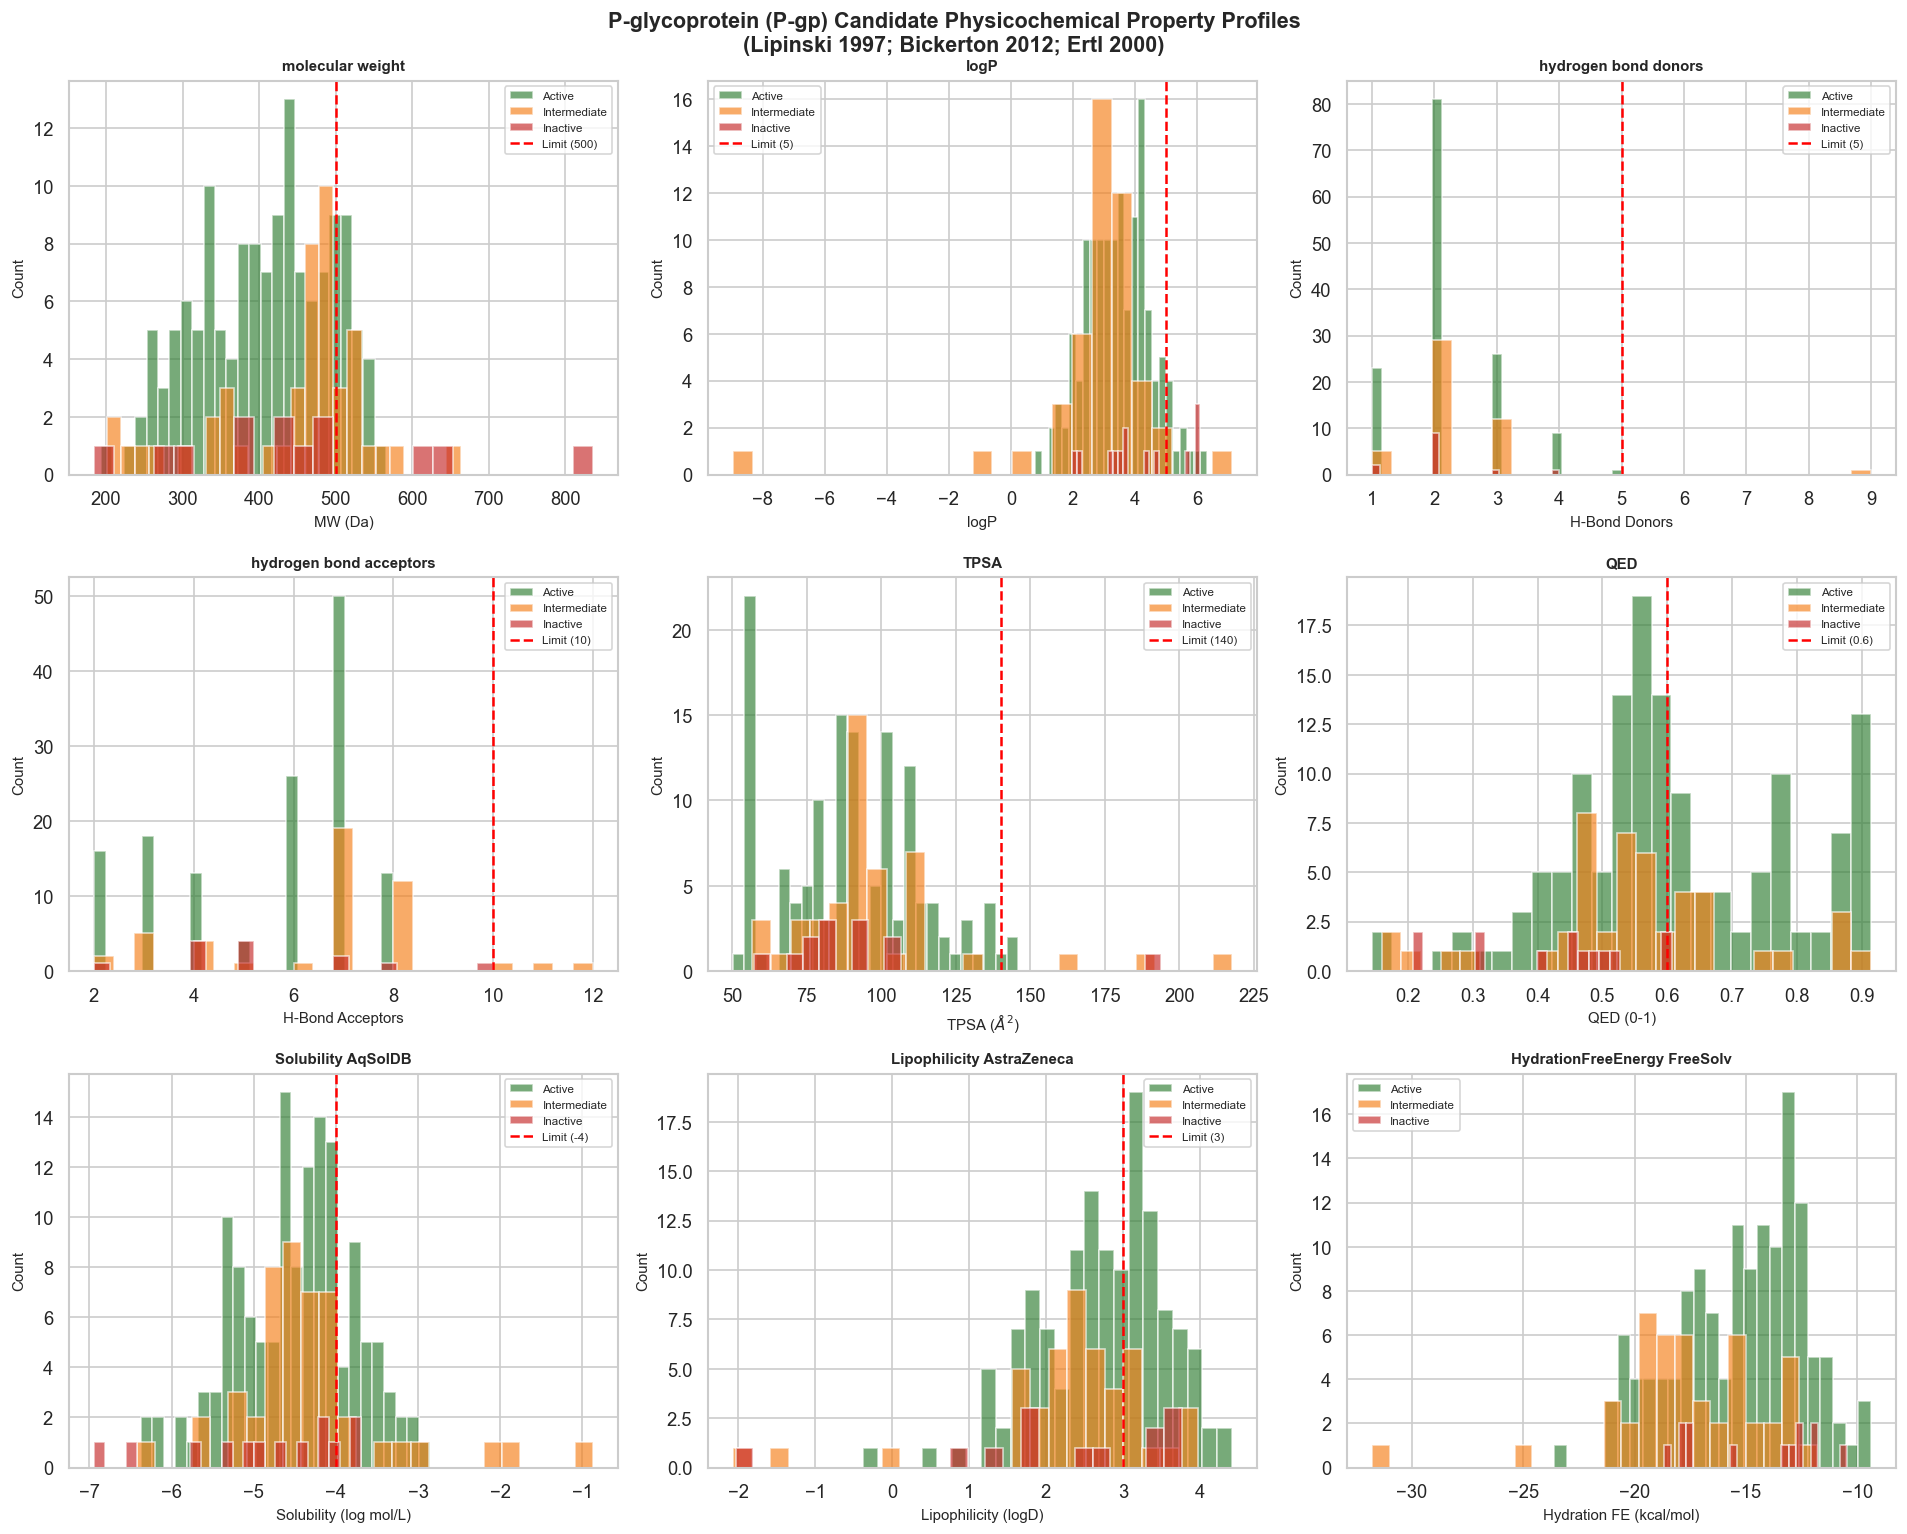

[SAVED] Serialized visual distribution mapping to admet_physicochemical_01.png


In [5]:
# ============================================================================
# Phase 2.3 — Physicochemical Property Profiling
# References:
# - Lipinski CA et al. (1997) Adv Drug Deliv Rev 23(1-3):3-25
# - Wildman SA & Crippen GM (1999) J Chem Inf Comput Sci 39(5):868-873
# - Ertl P et al. (2000) J Med Chem 43(20):3714-3717
# - Bickerton GR et al. (2012) Nat Chem 4(2):90-98
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Enforce established publication-ready palettes
PALETTE = {'safe':'#2E7D32', 'moderate':'#F57F17', 'risk':'#C62828', 'neutral':'#1565C0', 'drugbank':'#6A1B9A'}
act_colors = {'Active': PALETTE['safe'], 'Intermediate': PALETTE['moderate'], 'Inactive': PALETTE['risk']}

# Canonical physical property target arrays
requested_cols = [
    'molecular_weight', 'logP', 'hydrogen_bond_donors',
    'hydrogen_bond_acceptors', 'tpsa', 'QED',
    'Solubility_AqSolDB', 'Lipophilicity_AstraZeneca',
    'HydrationFreeEnergy_FreeSolv'
]

# Map columns dynamically to address case variations (e.g., resolving 'tpsa' vs 'TPSA')
source_columns = df_admet.columns.tolist()
mapping_dict = {}
for req in requested_cols:
    match = next((c for c in source_columns if c.lower() == req.lower()), None)
    if match:
        mapping_dict[req] = match
    else:
        # Fallback to map common synonyms if exact casing is missing
        if req.lower() == 'tpsa':
            match_alt = next((c for c in source_columns if 'tpsa' in c.lower()), None)
            if match_alt:
                mapping_dict[req] = match_alt

# Extract valid identifiers present in the source index
resolved_physchem = [mapping_dict[k] for k in requested_cols if k in mapping_dict]

# Ensure baseline operational keys exist
id_col = 'chembl_id' if 'chembl_id' in df_admet.columns else (df_admet.columns[0])
activity_col = 'activity' if 'activity' in df_admet.columns else 'Activity'

pc_data = df_admet[[id_col, activity_col] + resolved_physchem].copy()

print('Physicochemical Property Statistics')
print('=' * 75)
print(f'  {"Property":<38} {"Mean":>8} {"Std":>7} {"Min":>8} {"Max":>8}')
print('  ' + '-'*75)
for col in resolved_physchem:
    d = pc_data[col].dropna()
    if len(d) > 0:
        print(f'  {col:<38} {d.mean():>8.3f} {d.std():>7.3f} {d.min():>8.3f} {d.max():>8.3f}')

# Quantify rule compliance matrices using verified column positions
lip_col = next((c for c in source_columns if c.lower() == 'lipinski'), None)
qed_col = next((c for c in source_columns if c.lower() == 'qed'), None)

if lip_col and len(df_admet[lip_col].dropna()) > 0:
    lip = df_admet[lip_col].dropna()
    print(f'\nLipinski Ro5 compliance : {int((lip>=0.5).sum())}/{len(lip)} ({100*(lip>=0.5).mean():.1f}%)')
if qed_col and len(df_admet[qed_col].dropna()) > 0:
    qed = df_admet[qed_col].dropna()
    print(f'QED >= 0.6 (drug-like)  : {int((qed>=0.6).sum())}/{len(qed)} ({100*(qed>=0.6).mean():.1f}%)')
    print(f'Mean QED                : {qed.mean():.3f}')

# Initialize multi-panel visualization framework
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('P-glycoprotein (P-gp) Candidate Physicochemical Property Profiles\n(Lipinski 1997; Bickerton 2012; Ertl 2000)',
             fontsize=13, fontweight='bold')

xlabels = [
    'MW (Da)', 'logP', 'H-Bond Donors', 'H-Bond Acceptors', r'TPSA ($\AA^2$)',
    'QED (0-1)', 'Solubility (log mol/L)', 'Lipophilicity (logD)', 'Hydration FE (kcal/mol)'
]
thresholds = [500, 5, 5, 10, 140, 0.6, -4, 3, None]  # Optimized TPSA threshold boundary to 140 for systemic filtering

for i, ax in enumerate(axes.flat):
    if i >= len(resolved_physchem):
        ax.axis('off')
        continue
        
    col = resolved_physchem[i]
    xlabel = xlabels[i]
    thresh = thresholds[i]
    
    unique_classes = [c for c in ['Active', 'Intermediate', 'Inactive'] if c in pc_data[activity_col].unique()]
    
    for cls in unique_classes:
        subset = pc_data[pc_data[activity_col] == cls][col].dropna()
        if len(subset) > 0:
            ax.hist(subset, bins=25, alpha=0.65, color=act_colors[cls], label=cls, edgecolor='white')
            
    if thresh is not None:
        ax.axvline(thresh, color='red', linestyle='--', lw=1.5, label=f'Limit ({thresh})')
        
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()

# Standardized serialization block to preserve an ordered empirical audit trail
output_fig_path = 'admet_physicochemical_01.png'
plt.savefig(output_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] Serialized visual distribution mapping to {output_fig_path}')

## Cell 4 - Drug-Likeness Assessment and Structural Alert Profiling

Beyond Lipinski's Rule of Five, ADMET-AI evaluates three structural alert filters:

**PAINS (Pan-Assay Interference Compounds):** 480 substructure alerts encoding compounds
causing artifactual activity through redox cycling, metal chelation, or covalent modification.
Reference: Baell JB & Holloway GA (2010) J Med Chem 53(7):2719-2740. doi:10.1021/jm901137j

**BRENK Alerts:** 105 substructure alerts for reactive or unstable functional groups.
Reference: Brenk R et al. (2008) ChemMedChem 3(3):435-444. doi:10.1002/cmdc.200700139

**NIH Alerts:** Substructure filters from the NIH Molecular Libraries program.
Reference: Doveston RG et al. (2015) MedChemComm 6(12):2150-2154. doi:10.1039/c5md00316d

**QED (Quantitative Estimate of Drug-likeness):** Composite desirability score integrating
8 physicochemical properties, calibrated against approved drugs (0=least, 1=most drug-like).
Reference: Bickerton GR et al. (2012) Nat Chem 4(2):90-98. doi:10.1038/nchem.1243

Drug-Likeness and Structural Alert Summary
  Lipinski Ro5 pass: 200/200 (100.0%)
  Mean QED         : 0.585
  QED >= 0.6       : 77 (38.5%)
  PAINS (Baell 2010) flagged: 10/200 (5.0%)
  BRENK (Brenk 2008) flagged: 32/200 (16.0%)
  NIH (Doveston 2015) flagged: 8/200 (4.0%)


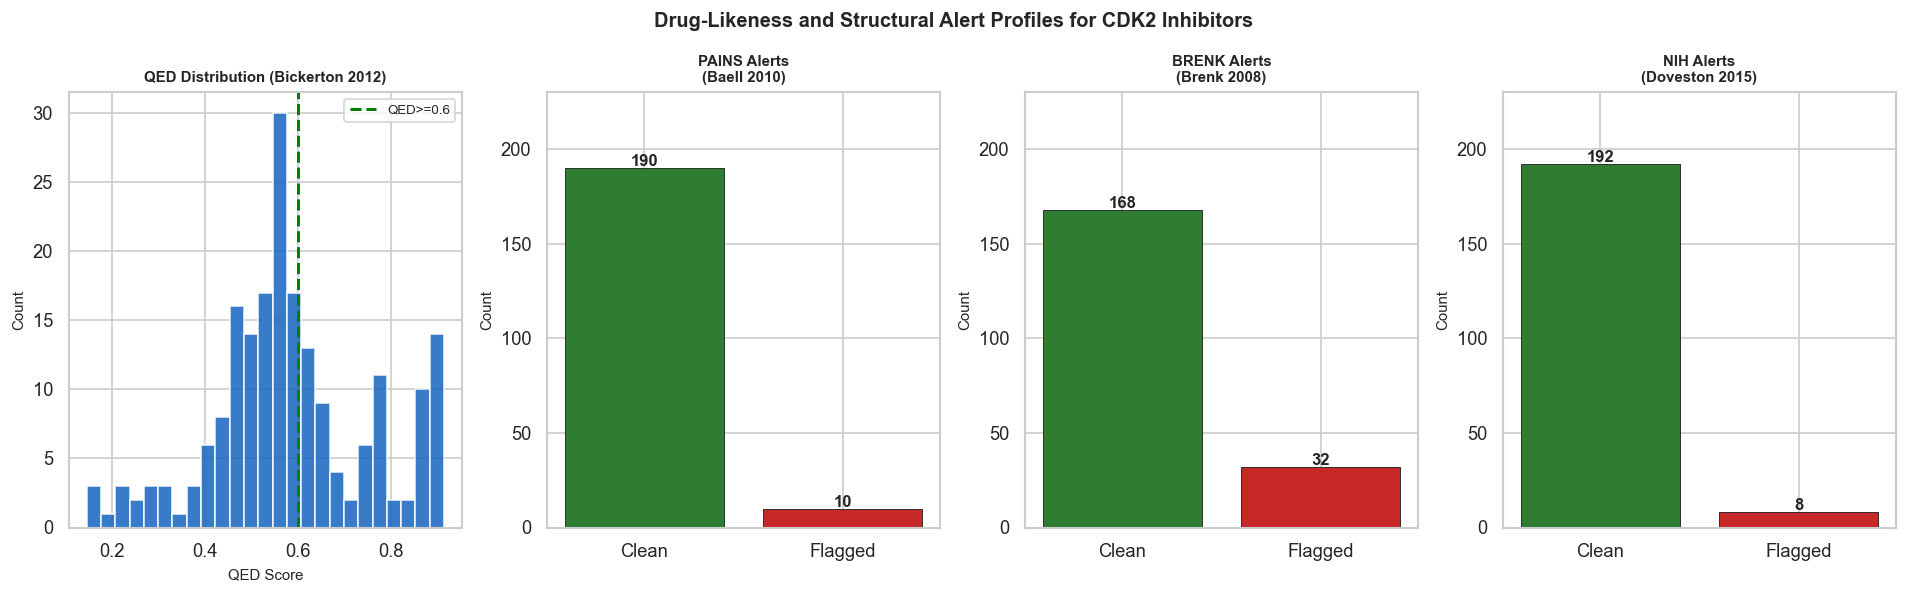

[SAVED] admet_druglikeness_alerts.png


In [6]:
# ============================================================
# CELL 4 - Drug-likeness and structural alert profiling
# References:
# - Baell JB & Holloway GA (2010) J Med Chem 53(7):2719-2740
# - Brenk R et al. (2008) ChemMedChem 3(3):435-444
# - Bickerton GR et al. (2012) Nat Chem 4(2):90-98
# - Lipinski CA et al. (1997) Adv Drug Deliv Rev 23(1-3):3-25
# ============================================================
total = len(df_admet)
lip_pass = df_admet['Lipinski'].fillna(0)
qed_vals = df_admet['QED'].dropna()

print('Drug-Likeness and Structural Alert Summary')
print('=' * 55)
print(f'  Lipinski Ro5 pass: {(lip_pass>=0.5).sum()}/{total} ({100*(lip_pass>=0.5).mean():.1f}%)')
print(f'  Mean QED         : {qed_vals.mean():.3f}')
print(f'  QED >= 0.6       : {(qed_vals>=0.6).sum()} ({100*(qed_vals>=0.6).mean():.1f}%)')

for col, label in [('PAINS_alert','PAINS (Baell 2010)'),
                   ('BRENK_alert','BRENK (Brenk 2008)'),
                   ('NIH_alert',  'NIH (Doveston 2015)')]:
    flagged = (df_admet[col].fillna(0) >= 0.5).sum()
    print(f'  {label} flagged: {flagged}/{total} ({100*flagged/total:.1f}%)')

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Drug-Likeness and Structural Alert Profiles for CDK2 Inhibitors', fontsize=12, fontweight='bold')

axes[0].hist(qed_vals, bins=25, color=PALETTE['neutral'], edgecolor='white', alpha=0.85)
axes[0].axvline(0.6, color='green', linestyle='--', lw=1.8, label='QED>=0.6')
axes[0].set_xlabel('QED Score', fontsize=9)
axes[0].set_ylabel('Count', fontsize=9)
axes[0].set_title('QED Distribution (Bickerton 2012)', fontsize=9)
axes[0].legend(fontsize=8)

for ax, col, title in zip(axes[1:],
    ['PAINS_alert','BRENK_alert','NIH_alert'],
    ['PAINS Alerts\n(Baell 2010)','BRENK Alerts\n(Brenk 2008)','NIH Alerts\n(Doveston 2015)']):
    vals  = df_admet[col].fillna(0)
    flagged = (vals>=0.5).sum()
    clean   = total - flagged
    bars = ax.bar(['Clean','Flagged'],[clean,flagged],
                  color=[PALETTE['safe'],PALETTE['risk']],edgecolor='k',linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                str(int(bar.get_height())),ha='center',fontweight='bold')
    ax.set_ylabel('Count',fontsize=9)
    ax.set_title(title,fontsize=9)
    ax.set_ylim(0, total*1.15)

plt.tight_layout()
plt.savefig('admet_druglikeness_alerts.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_druglikeness_alerts.png')

## Cell 5 - Absorption Property Profiling

Absorption determines how much drug enters systemic circulation after oral dosing.
ADMET-AI predicts five absorption endpoints:

| Endpoint | Measurement | Threshold | Reference |
|----------|------------|---------|----------|
| Caco2_Wang | Intestinal permeability (log cm/s) | > -5.15 | Wang NN et al. (2016) Mol Pharm 13(12):4124 |
| HIA_Hou | Human intestinal absorption (binary) | >= 30% | Hou T et al. (2007) J Chem Inf Model 47(1):208 |
| Bioavailability_Ma | Oral bioavailability F20% (binary) | F > 20% | Ma CY et al. (2008) J Chem Inf Model 48(2):255 |
| PAMPA_NCATS | Passive membrane permeability | Higher=better | Siramshetty VB et al. (2021) NCATS |
| Pgp_Broccatelli | P-gp efflux substrate (binary) | Non-substrate preferred | Broccatelli F et al. (2011) J Med Chem 54(6):1740 |

Absorption Property Summary
  Caco2_Wang: mean=-5.172 std=0.353 range=[-7.095,-4.549]
  HIA_Hou: Favourable: 198/200 (99.0%)
  Bioavailability_Ma: Favourable: 197/200 (98.5%)
  PAMPA_NCATS: mean=0.767 std=0.184 range=[0.026,0.979]
  Pgp_Broccatelli: Non-substrate (fav): 108/200 (54.0%)


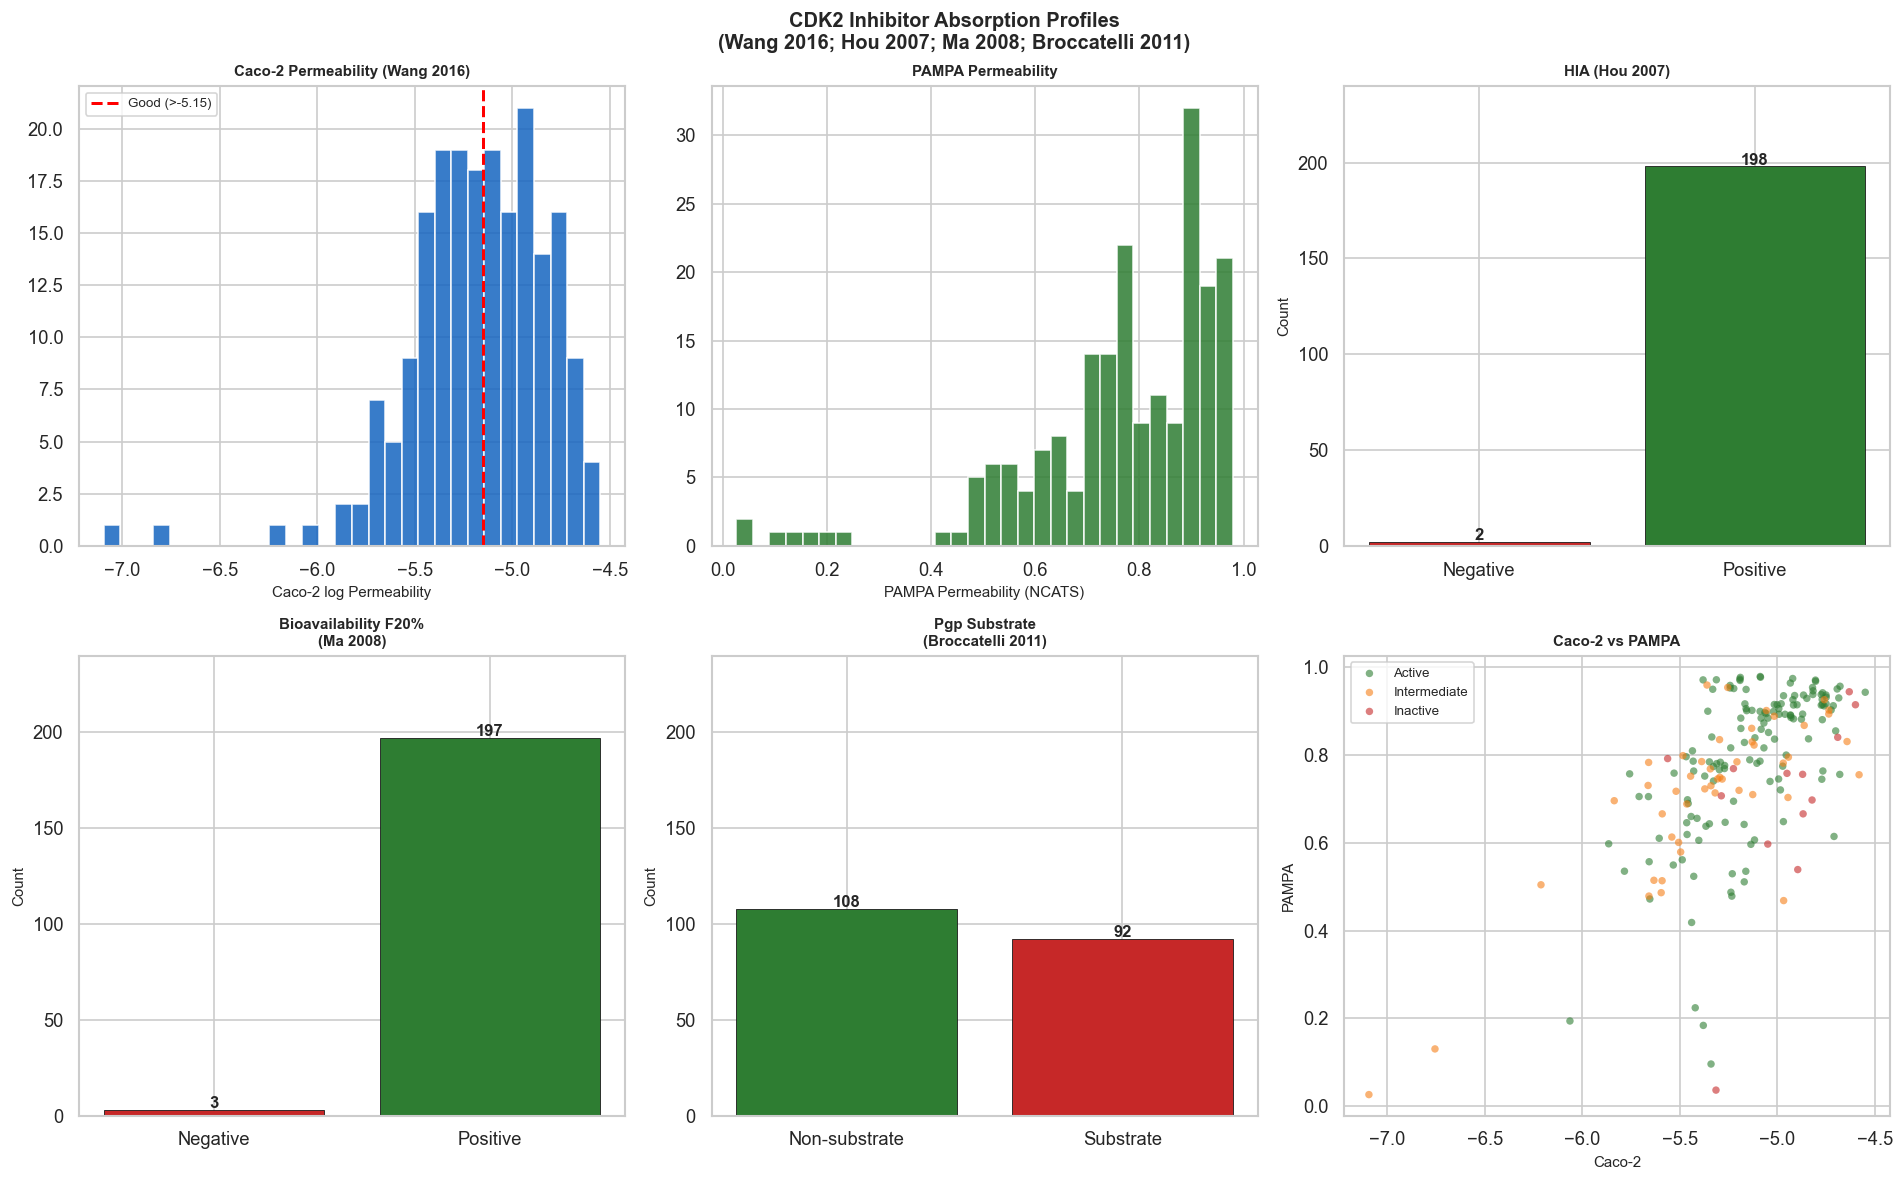

[SAVED] admet_absorption.png


In [7]:
# ============================================================
# CELL 5 - Absorption profiling
# References:
# - Caco-2: Wang NN et al. (2016) Mol Pharm 13(12):4124-4135
# - HIA: Hou T et al. (2007) J Chem Inf Model 47(1):208-218
# - Bioavailability: Ma CY et al. (2008) J Chem Inf Model 48(2):255-259
# - Pgp: Broccatelli F et al. (2011) J Med Chem 54(6):1740-1751
# ============================================================
abs_cols  = ['Caco2_Wang','HIA_Hou','Bioavailability_Ma','PAMPA_NCATS','Pgp_Broccatelli']
abs_types = ['cont','bin','bin','cont','bin']
abs_sdir  = ['high','high','high','high','low']

print('Absorption Property Summary')
print('='*60)
for col, atype, sdir in zip(abs_cols, abs_types, abs_sdir):
    d = df_admet[col].dropna()
    if atype == 'bin':
        n_fav = (d>=0.5).sum() if sdir=='high' else (d<0.5).sum()
        lbl   = 'Favourable' if sdir=='high' else 'Non-substrate (fav)'
        print(f'  {col}: {lbl}: {n_fav}/{len(d)} ({100*n_fav/len(d):.1f}%)')
    else:
        print(f'  {col}: mean={d.mean():.3f} std={d.std():.3f} range=[{d.min():.3f},{d.max():.3f}]')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('CDK2 Inhibitor Absorption Profiles\n(Wang 2016; Hou 2007; Ma 2008; Broccatelli 2011)',
             fontsize=12, fontweight='bold')

caco2 = df_admet['Caco2_Wang'].dropna()
axes[0,0].hist(caco2,bins=30,color=PALETTE['neutral'],edgecolor='white',alpha=0.85)
axes[0,0].axvline(-5.15,color='red',linestyle='--',lw=1.8,label='Good (>-5.15)')
axes[0,0].set_xlabel('Caco-2 log Permeability',fontsize=9)
axes[0,0].set_title('Caco-2 Permeability (Wang 2016)',fontsize=9)
axes[0,0].legend(fontsize=8)

pampa = df_admet['PAMPA_NCATS'].dropna()
axes[0,1].hist(pampa,bins=30,color=PALETTE['safe'],edgecolor='white',alpha=0.85)
axes[0,1].set_xlabel('PAMPA Permeability (NCATS)',fontsize=9)
axes[0,1].set_title('PAMPA Permeability',fontsize=9)

for ax, col, lbl, sdir in zip([axes[0,2],axes[1,0],axes[1,1]],
    ['HIA_Hou','Bioavailability_Ma','Pgp_Broccatelli'],
    ['HIA (Hou 2007)','Bioavailability F20%\n(Ma 2008)','Pgp Substrate\n(Broccatelli 2011)'],
    ['high','high','low']):
    vals  = df_admet[col].dropna()
    pos   = (vals>=0.5).sum(); neg = len(vals)-pos
    if sdir=='high':
        bcolors=[PALETTE['risk'],PALETTE['safe']]; blabels=['Negative','Positive']
    else:
        bcolors=[PALETTE['safe'],PALETTE['risk']]; blabels=['Non-substrate','Substrate']
    bars = ax.bar(blabels,[neg,pos],color=bcolors,edgecolor='k',linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
                str(int(bar.get_height())),ha='center',fontweight='bold')
    ax.set_ylabel('Count',fontsize=9); ax.set_title(lbl,fontsize=9)
    ax.set_ylim(0,len(vals)*1.2)

sc = df_admet[['Caco2_Wang','PAMPA_NCATS','activity']].dropna()
for cls,clr in act_colors.items():
    sub = sc[sc['activity']==cls]
    axes[1,2].scatter(sub['Caco2_Wang'],sub['PAMPA_NCATS'],c=clr,label=cls,alpha=0.6,s=20,edgecolors='none')
axes[1,2].set_xlabel('Caco-2',fontsize=9); axes[1,2].set_ylabel('PAMPA',fontsize=9)
axes[1,2].set_title('Caco-2 vs PAMPA',fontsize=9); axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('admet_absorption.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_absorption.png')

## Cell 6 - Distribution Property Profiling

Distribution describes how a drug spreads from the bloodstream into tissues after absorption.

**BBB_Martins:** Blood-brain barrier penetration (binary). Essential for CNS drugs; may be
undesirable for peripheral targets. Reference: Martins IF et al. (2012) J Chem Inf Model
52(7):1686-1697. doi:10.1021/ci300124c

**PPBR_AZ:** Plasma protein binding (%). Only the unbound fraction exerts pharmacological
activity. High PPBR (>95%) severely restricts free drug concentration.
Reference: Gleeson MP (2008) J Med Chem 51(4):817-834. doi:10.1021/jm701122q

**VDss_Lombardo:** Volume of distribution at steady state (L/kg). High VDss (>1 L/kg)
indicates extensive tissue distribution beyond the plasma compartment.
Reference: Lombardo F et al. (2002) J Med Chem 45(13):2867-2876. doi:10.1021/jm0200409

Distribution Property Summary
BBB penetrant (Martins 2012): 140/200 (70.0%)
Mean PPBR (AZ)              : 89.5%
PPBR >= 90%                 : 110/200 (55.0%)
Mean VDss (Lombardo 2002)   : 7.723 L/kg
VDss >= 1 L/kg              : 182/200 (91.0%)


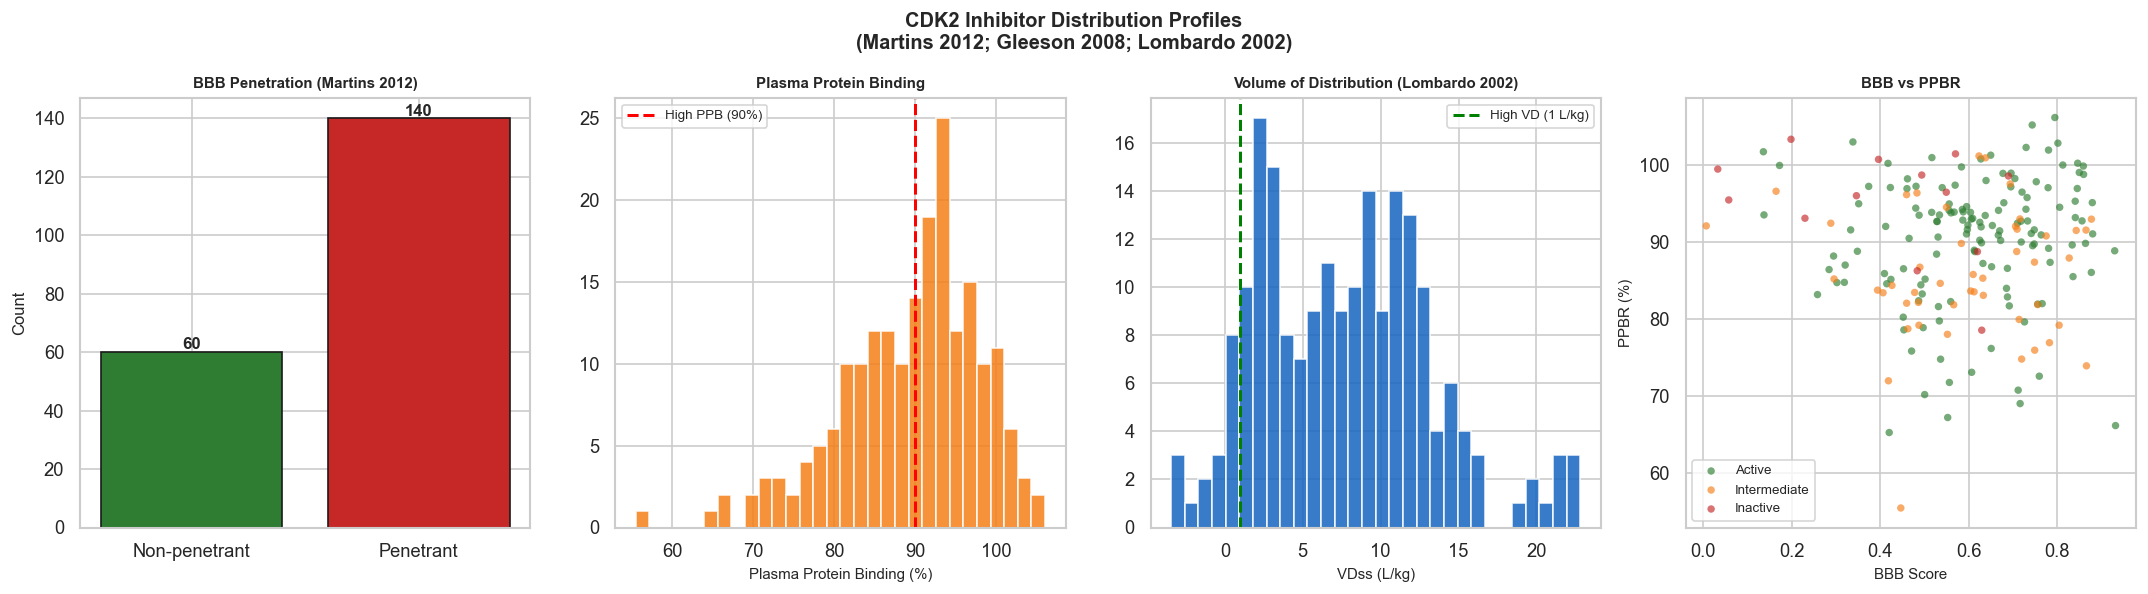

[SAVED] admet_distribution.png


In [8]:
# ============================================================
# CELL 6 - Distribution profiling
# References:
# - BBB: Martins IF et al. (2012) J Chem Inf Model 52(7):1686-1697
# - PPBR: Gleeson MP (2008) J Med Chem 51(4):817-834
# - VDss: Lombardo F et al. (2002) J Med Chem 45(13):2867-2876
# ============================================================
bbb  = df_admet['BBB_Martins'].dropna()
ppbr = df_admet['PPBR_AZ'].dropna()
vdss = df_admet['VDss_Lombardo'].dropna()

print('Distribution Property Summary')
print('='*55)
bbb_pen = (bbb>=0.5).sum()
print(f'BBB penetrant (Martins 2012): {bbb_pen}/{len(bbb)} ({100*bbb_pen/len(bbb):.1f}%)')
print(f'Mean PPBR (AZ)              : {ppbr.mean():.1f}%')
print(f'PPBR >= 90%                 : {(ppbr>=90).sum()}/{len(ppbr)} ({100*(ppbr>=90).mean():.1f}%)')
print(f'Mean VDss (Lombardo 2002)   : {vdss.mean():.3f} L/kg')
print(f'VDss >= 1 L/kg              : {(vdss>=1).sum()}/{len(vdss)} ({100*(vdss>=1).mean():.1f}%)')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('CDK2 Inhibitor Distribution Profiles\n(Martins 2012; Gleeson 2008; Lombardo 2002)',
             fontsize=12, fontweight='bold')

axes[0].bar(['Non-penetrant','Penetrant'],[len(bbb)-bbb_pen,bbb_pen],
            color=[PALETTE['safe'],PALETTE['risk']],edgecolor='k')
for bar,val in zip(axes[0].patches,[len(bbb)-bbb_pen,bbb_pen]):
    axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,str(val),ha='center',fontweight='bold')
axes[0].set_title('BBB Penetration (Martins 2012)',fontsize=9); axes[0].set_ylabel('Count')

axes[1].hist(ppbr,bins=30,color=PALETTE['moderate'],edgecolor='white',alpha=0.85)
axes[1].axvline(90,color='red',linestyle='--',lw=1.8,label='High PPB (90%)')
axes[1].set_xlabel('Plasma Protein Binding (%)',fontsize=9)
axes[1].set_title('Plasma Protein Binding',fontsize=9); axes[1].legend(fontsize=8)

axes[2].hist(vdss,bins=30,color=PALETTE['neutral'],edgecolor='white',alpha=0.85)
axes[2].axvline(1.0,color='green',linestyle='--',lw=1.8,label='High VD (1 L/kg)')
axes[2].set_xlabel('VDss (L/kg)',fontsize=9)
axes[2].set_title('Volume of Distribution (Lombardo 2002)',fontsize=9); axes[2].legend(fontsize=8)

sc = df_admet[['BBB_Martins','PPBR_AZ','activity']].dropna()
for cls,clr in act_colors.items():
    sub = sc[sc['activity']==cls]
    axes[3].scatter(sub['BBB_Martins'],sub['PPBR_AZ'],c=clr,label=cls,alpha=0.65,s=20,edgecolors='none')
axes[3].set_xlabel('BBB Score',fontsize=9); axes[3].set_ylabel('PPBR (%)',fontsize=9)
axes[3].set_title('BBB vs PPBR',fontsize=9); axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig('admet_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_distribution.png')

## Cell 7 - CYP450 Metabolism: Five-Isoform Heatmap Analysis

CYP450 enzymes metabolise approximately 75% of all marketed drugs. ADMET-AI predicts
seven CYP450 endpoints across five isoforms:

| Isoform | % Drug Metabolism | Key Substrates | Reference |
|---------|-----------------|----------------|----------|
| CYP1A2 | ~15% | Caffeine, Clozapine | Veith H et al. (2009) Nat Biotechnol 27(11):1050 |
| CYP2C9 | ~20% | Warfarin, Ibuprofen | Veith H et al. (2009) Nat Biotechnol 27(11):1050 |
| CYP2C19 | ~15% | Omeprazole, Clopidogrel | Veith H et al. (2009) Nat Biotechnol 27(11):1050 |
| CYP2D6 | ~25% | Codeine, Tamoxifen | Veith H et al. (2009) Nat Biotechnol 27(11):1050 |
| CYP3A4 | ~50% | Atorvastatin, Midazolam | Carbon-Mangels M & Hutter MC (2011) Mol Inform 30:885 |

CYP450 Metabolism Summary (probability >= 0.5 = predicted positive)
  Endpoint                                  Positive  Negative    % Pos
  -----------------------------------------------------------------
  CYP1A2 Inhibitor                                75       125    37.5%
  CYP2C19 Inhibitor                               62       138    31.0%
  CYP2C9 Inhibitor                                54       146    27.0%
  CYP2D6 Inhibitor                                21       179    10.5%
  CYP3A4 Inhibitor                                77       123    38.5%
  CYP2C9 Substrate                                 1       199     0.5%
  CYP2D6 Substrate                                 1       199     0.5%
  CYP3A4 Substrate                               157        43    78.5%


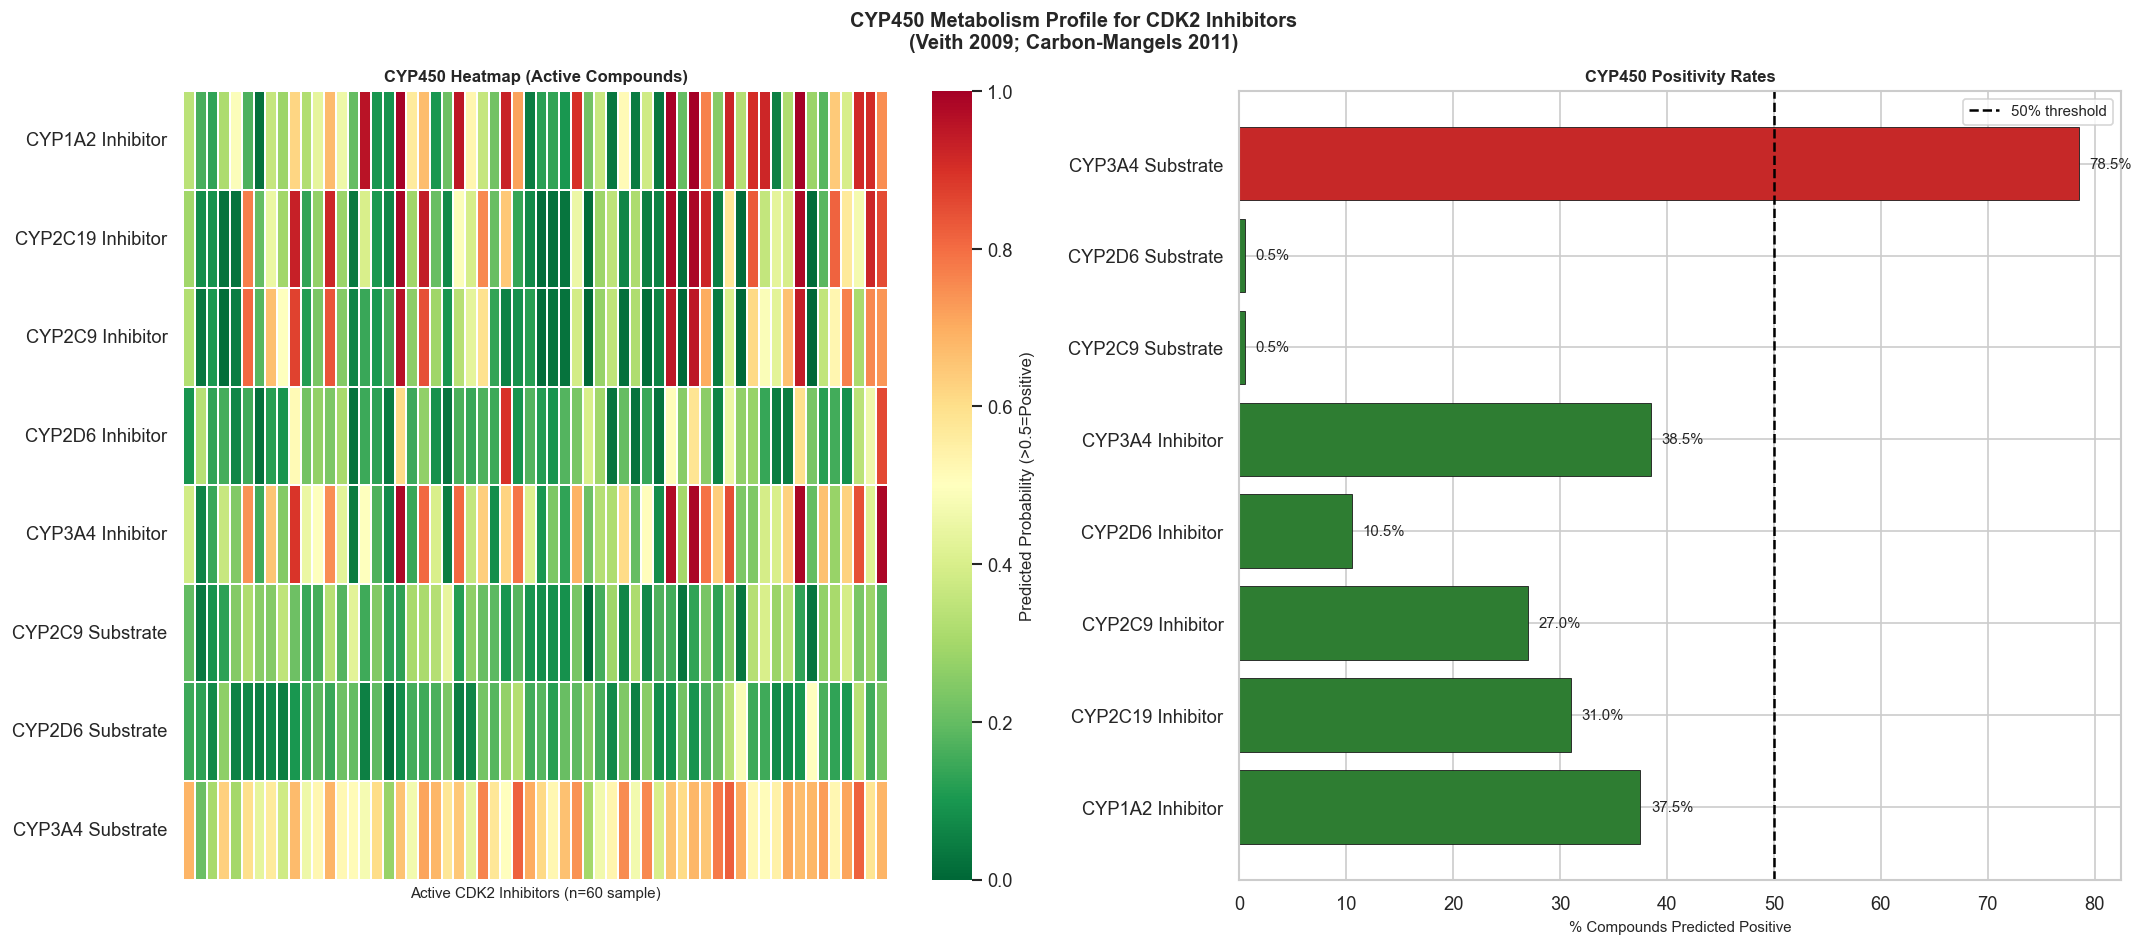

[SAVED] admet_cyp450_metabolism.png


In [9]:
# ============================================================
# CELL 7 - CYP450 metabolism heatmap
# References:
# - Veith H et al. (2009) Nat Biotechnol 27(11):1050-1055
# - Carbon-Mangels M & Hutter MC (2011) Mol Inform 30(10):885-895
# - Rendic S (2002) Drug Metab Rev 34(1-2):83-448
# ============================================================
cyp_inhib = {'CYP1A2_Veith':'CYP1A2 Inhibitor','CYP2C19_Veith':'CYP2C19 Inhibitor',
             'CYP2C9_Veith':'CYP2C9 Inhibitor','CYP2D6_Veith':'CYP2D6 Inhibitor',
             'CYP3A4_Veith':'CYP3A4 Inhibitor'}
cyp_subs  = {'CYP2C9_Substrate_CarbonMangels':'CYP2C9 Substrate',
             'CYP2D6_Substrate_CarbonMangels':'CYP2D6 Substrate',
             'CYP3A4_Substrate_CarbonMangels':'CYP3A4 Substrate'}
all_cyp   = {**cyp_inhib, **cyp_subs}

print('CYP450 Metabolism Summary (probability >= 0.5 = predicted positive)')
print('='*65)
print(f'  {"Endpoint":<40} {"Positive":>9} {"Negative":>9} {"% Pos":>8}')
print('  '+'-'*65)
n = len(df_admet)
for col, label in all_cyp.items():
    vals = df_admet[col].dropna()
    pos  = (vals>=0.5).sum()
    print(f'  {label:<40} {pos:>9} {len(vals)-pos:>9} {100*pos/len(vals):>7.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('CYP450 Metabolism Profile for CDK2 Inhibitors\n(Veith 2009; Carbon-Mangels 2011)',
             fontsize=12, fontweight='bold')

active_sub = df_admet[df_admet['activity']=='Active'].head(60)
cyp_matrix = active_sub[list(all_cyp.keys())].fillna(0.5)
import seaborn as sns
sns.heatmap(cyp_matrix.T, ax=axes[0], cmap='RdYlGn_r', vmin=0, vmax=1,
            yticklabels=list(all_cyp.values()), xticklabels=False,
            linewidths=0.1, linecolor='white',
            cbar_kws={'label':'Predicted Probability (>0.5=Positive)'})
axes[0].set_xlabel('Active CDK2 Inhibitors (n=60 sample)',fontsize=9)
axes[0].set_title('CYP450 Heatmap (Active Compounds)',fontsize=10)

pct_pos   = [100*(df_admet[col].dropna()>=0.5).mean() for col in all_cyp]
bar_colors= [PALETTE['risk'] if p>50 else PALETTE['safe'] for p in pct_pos]
bars = axes[1].barh(list(all_cyp.values()),pct_pos,color=bar_colors,edgecolor='k',linewidth=0.5)
axes[1].axvline(50,color='black',linestyle='--',lw=1.5,label='50% threshold')
for bar,pct in zip(bars,pct_pos):
    axes[1].text(pct+1,bar.get_y()+bar.get_height()/2,f'{pct:.1f}%',va='center',fontsize=9)
axes[1].set_xlabel('% Compounds Predicted Positive',fontsize=9)
axes[1].set_title('CYP450 Positivity Rates',fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('admet_cyp450_metabolism.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_cyp450_metabolism.png')

## Cell 8 - Excretion Property Profiling

Excretion is the elimination of drugs and metabolites, primarily via renal and hepatic routes.
ADMET-AI predicts three excretion endpoints:

**Clearance_Hepatocyte_AZ:** Rate of liver clearance in hepatocytes (uL/min/10^6 cells).
High clearance = rapid elimination = short half-life.
Reference: AstraZeneca internal dataset.

**Clearance_Microsome_AZ:** CYP450-mediated clearance in liver microsomes (uL/min/mg protein).
Reference: AstraZeneca internal dataset.

**Half_Life_Obach:** Time for plasma concentration to fall 50% (hours).
Clinical categories: <1h very rapid; 1-8h short; 8-24h moderate; >24h long-acting.
Reference: Obach RS et al. (2008) Drug Metab Dispos 36(7):1385-1405. doi:10.1124/dmd.108.020479

Excretion Property Summary
  Clearance_Hepatocyte_AZ: mean=28.735 median=21.390 range=[-34.421,98.569]
  Clearance_Microsome_AZ: mean=34.941 median=29.437 range=[-8.456,111.144]
  Half_Life_Obach: mean=52.197 median=45.138 range=[-26.012,251.515]

Half-life categories (Obach 2008):
  < 1h  very rapid: 4 (2.0%)
  1-8h  short     : 1 (0.5%)
  8-24h moderate  : 30 (15.0%)
  > 24h long      : 165 (82.5%)


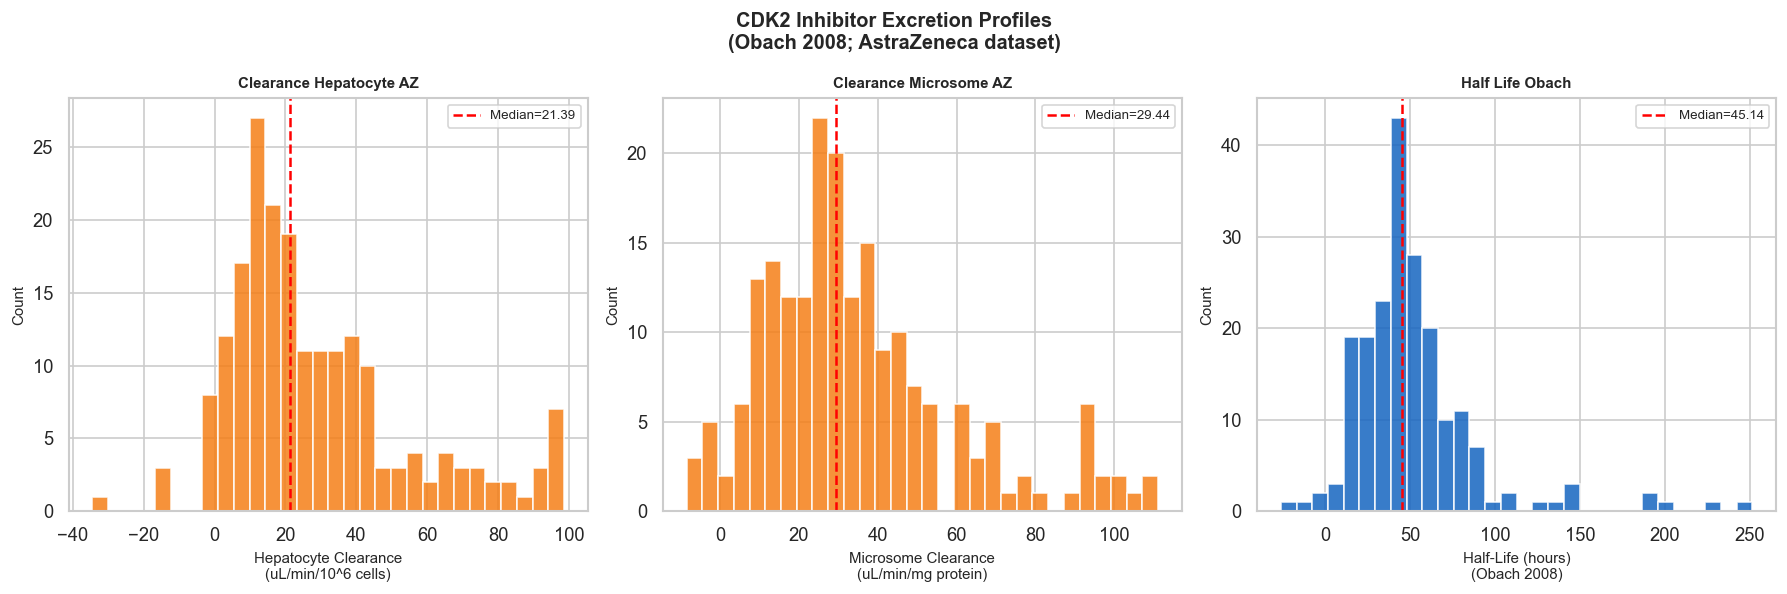

[SAVED] admet_excretion.png


In [10]:
# ============================================================
# CELL 8 - Excretion profiling
# References:
# - Obach RS et al. (2008) Drug Metab Dispos 36(7):1385-1405
# - AstraZeneca clearance dataset
# ============================================================
print('Excretion Property Summary')
print('='*55)
for col in ['Clearance_Hepatocyte_AZ','Clearance_Microsome_AZ','Half_Life_Obach']:
    d = df_admet[col].dropna()
    print(f'  {col}: mean={d.mean():.3f} median={d.median():.3f} range=[{d.min():.3f},{d.max():.3f}]')

hl = df_admet['Half_Life_Obach'].dropna()
print(f'\nHalf-life categories (Obach 2008):')
print(f'  < 1h  very rapid: {(hl<1).sum()} ({100*(hl<1).mean():.1f}%)')
print(f'  1-8h  short     : {((hl>=1)&(hl<8)).sum()} ({100*((hl>=1)&(hl<8)).mean():.1f}%)')
print(f'  8-24h moderate  : {((hl>=8)&(hl<24)).sum()} ({100*((hl>=8)&(hl<24)).mean():.1f}%)')
print(f'  > 24h long      : {(hl>=24).sum()} ({100*(hl>=24).mean():.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('CDK2 Inhibitor Excretion Profiles\n(Obach 2008; AstraZeneca dataset)',
             fontsize=12, fontweight='bold')
for ax, col, lbl, color in zip(axes,
    ['Clearance_Hepatocyte_AZ','Clearance_Microsome_AZ','Half_Life_Obach'],
    ['Hepatocyte Clearance\n(uL/min/10^6 cells)',
     'Microsome Clearance\n(uL/min/mg protein)',
     'Half-Life (hours)\n(Obach 2008)'],
    [PALETTE['moderate'],PALETTE['moderate'],PALETTE['neutral']]):
    d = df_admet[col].dropna()
    ax.hist(d,bins=30,color=color,edgecolor='white',alpha=0.85)
    ax.axvline(d.median(),color='red',linestyle='--',lw=1.5,label=f'Median={d.median():.2f}')
    ax.set_xlabel(lbl,fontsize=9); ax.set_ylabel('Count',fontsize=9)
    ax.set_title(col.replace('_',' '),fontsize=9); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('admet_excretion.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_excretion.png')

## Cell 9 - Toxicity Property Profiling

Toxicity prediction is the most critical ADMET component because toxic liabilities discovered
in clinical trials represent both patient safety risks and leading causes of late-stage failure.

| Endpoint | Description | Reference |
|----------|------------|----------|
| hERG | hERG K+ channel inhibition causing cardiac arrhythmia | Sanguinetti MC & Tristani-Firouzi M (2006) Nature 440:463-469 |
| AMES | Bacterial mutagenicity (Salmonella typhimurium) | Mortelmans K & Zeiger E (2000) Mutat Res 455:29-60 |
| DILI | Drug-induced liver injury | Xu Y et al. (2015) J Chem Inf Model 55(10):2085-2095 |
| ClinTox | Clinical trial toxicity failure | Gayvert KM et al. (2016) Cell Chem Biol 23(10):1294-1301 |
| Carcinogens_Lagunin | Carcinogenic potential | Lagunin A et al. (2009) Mol Inform 28(8):806-810 |
| LD50_Zhu | Acute oral toxicity in rats (log mol/kg) | Zhu H et al. (2009) Chem Res Toxicol 22(12):1913-1921 |
| Skin_Reaction | Skin sensitisation | Mansouri K et al. (2016) J Cheminform 8:11 |

Toxicity Summary (prob >= 0.5 = predicted toxic)
  Endpoint                                        Risk   Safe   % Risk
  --------------------------------------------------------------------
  hERG Inhibition (Sanguinetti 2006)               147     53    73.5%
  AMES Mutagenicity (Mortelmans 2000)               62    138    31.0%
  Drug-Induced Liver Injury (Xu 2015)              199      1    99.5%
  Clinical Toxicity (Gayvert 2016)                  81    119    40.5%
  Carcinogenicity (Lagunin 2009)                     5    195     2.5%
  Skin Sensitisation (Mansouri 2016)                13    187     6.5%

LD50 (Zhu 2009) log mol/kg: mean=2.729 median=2.801

Compounds with 0 tox flags: 0 (0.0%)
Compounds with 1 tox flag : 38 (19.0%)
Compounds with 2+ tox flags:162 (81.0%)


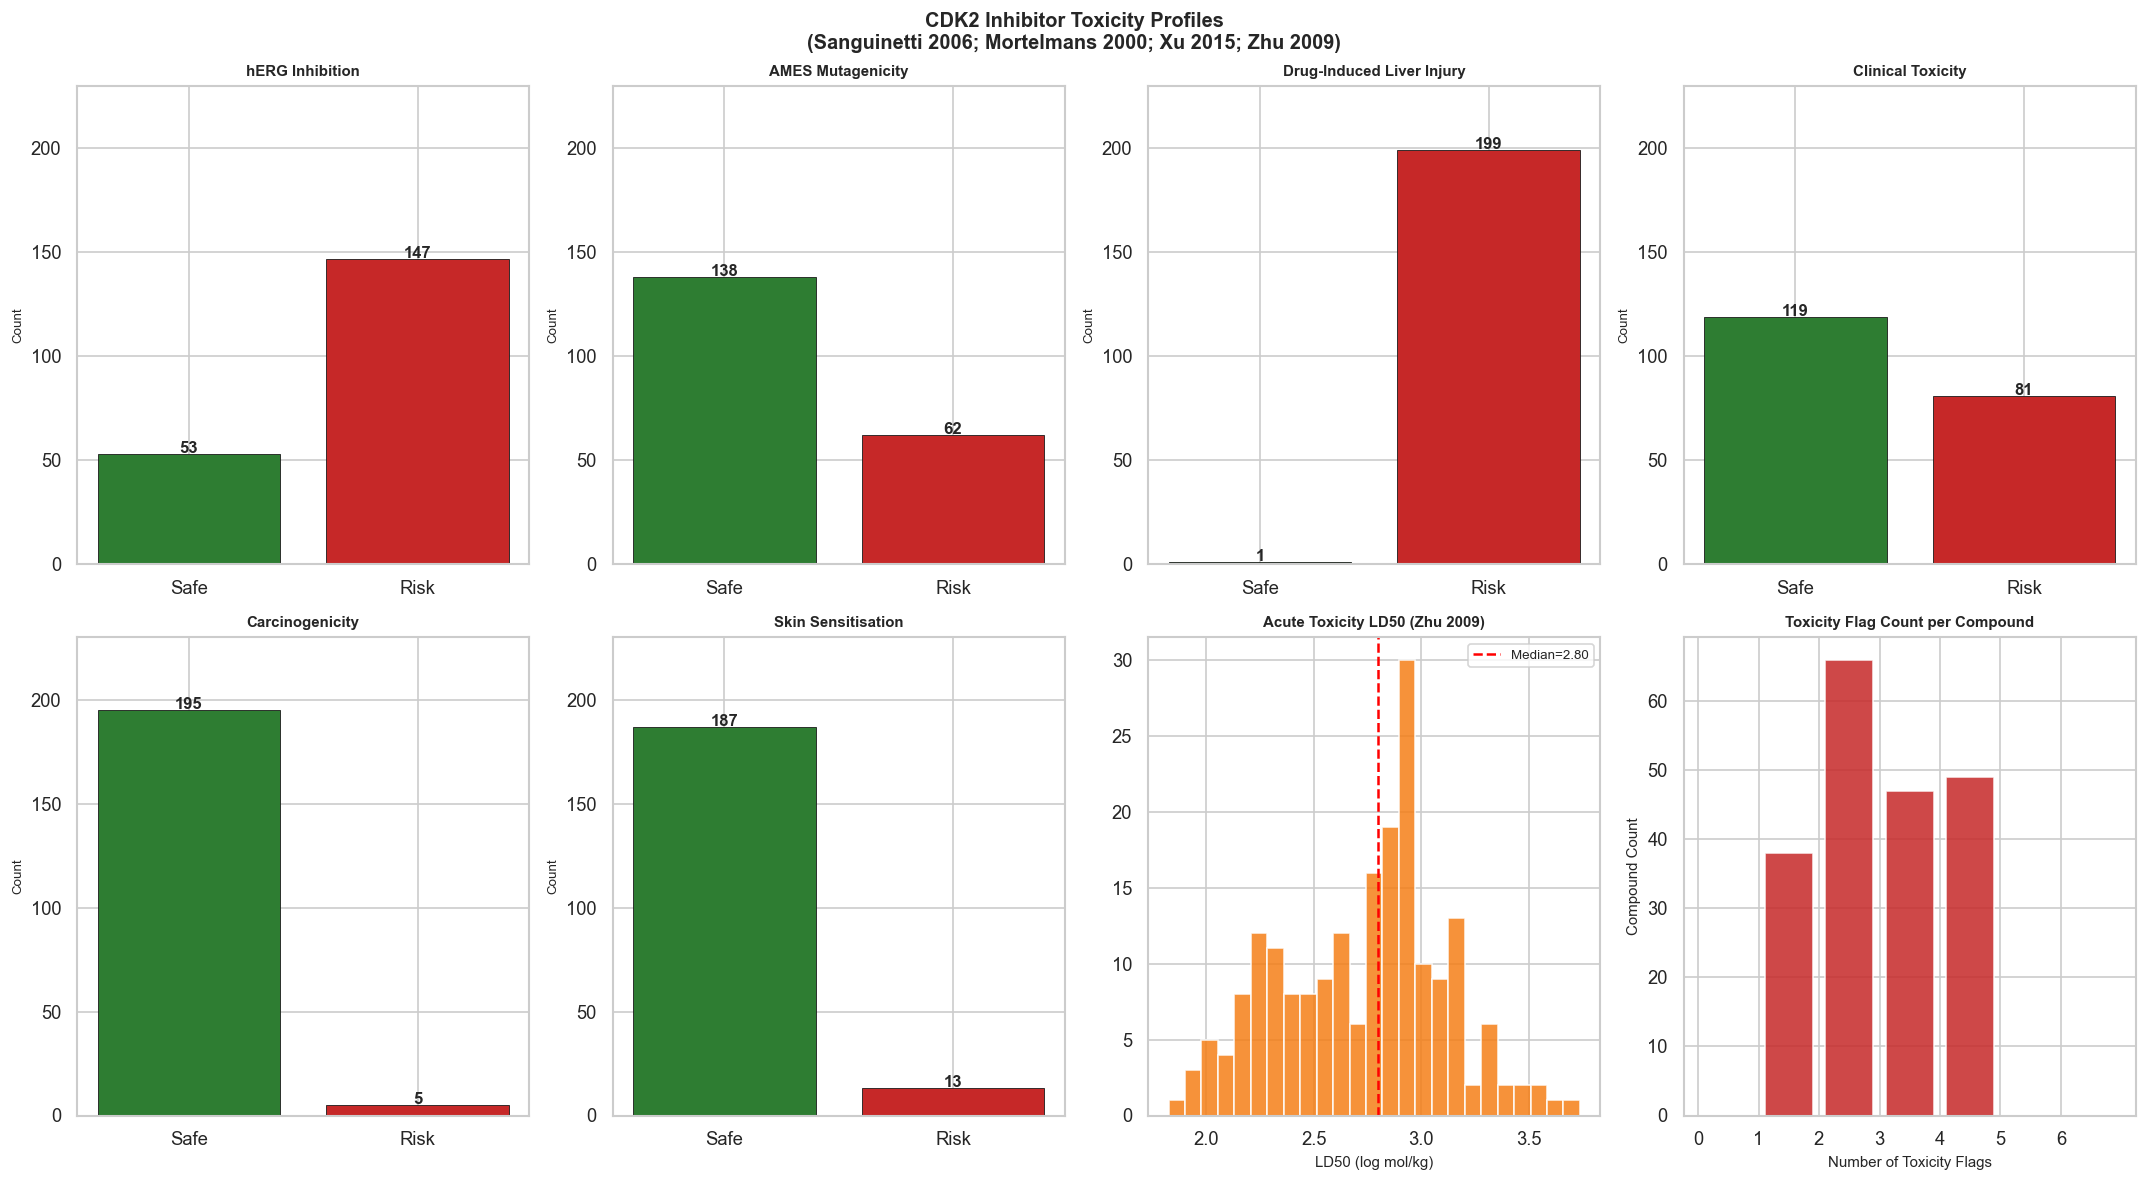

[SAVED] admet_toxicity.png


In [11]:
# ============================================================
# CELL 9 - Toxicity profiling
# References:
# - hERG: Sanguinetti MC & Tristani-Firouzi M (2006) Nature 440:463-469
# - AMES: Mortelmans K & Zeiger E (2000) Mutat Res 455(1-2):29-60
# - DILI: Xu Y et al. (2015) J Chem Inf Model 55(10):2085-2095
# - ClinTox: Gayvert KM et al. (2016) Cell Chem Biol 23(10):1294-1301
# - LD50: Zhu H et al. (2009) Chem Res Toxicol 22(12):1913-1921
# ============================================================
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
PALETTE = {'safe':'#2E7D32','moderate':'#F57F17','risk':'#C62828','neutral':'#1565C0','drugbank':'#6A1B9A'}
act_colors = {'Active':PALETTE['safe'],'Intermediate':PALETTE['moderate'],'Inactive':PALETTE['risk']}

tox_binary = {
    'hERG'              : 'hERG Inhibition (Sanguinetti 2006)',
    'AMES'              : 'AMES Mutagenicity (Mortelmans 2000)',
    'DILI'              : 'Drug-Induced Liver Injury (Xu 2015)',
    'ClinTox'           : 'Clinical Toxicity (Gayvert 2016)',
    'Carcinogens_Lagunin': 'Carcinogenicity (Lagunin 2009)',
    'Skin_Reaction'     : 'Skin Sensitisation (Mansouri 2016)',
}
n = len(df_admet)
print('Toxicity Summary (prob >= 0.5 = predicted toxic)')
print('='*68)
print(f'  {"Endpoint":<45} {"Risk":>6} {"Safe":>6} {"% Risk":>8}')
print('  '+'-'*68)
for col, label in tox_binary.items():
    d    = df_admet[col].dropna()
    risk = (d>=0.5).sum()
    print(f'  {label:<45} {risk:>6} {len(d)-risk:>6} {100*risk/len(d):>7.1f}%')

ld50 = df_admet['LD50_Zhu'].dropna()
print(f'\nLD50 (Zhu 2009) log mol/kg: mean={ld50.mean():.3f} median={ld50.median():.3f}')

# Multi-tox flag count
tox_flags = pd.DataFrame({col:(df_admet[col].fillna(0)>=0.5).astype(int) for col in tox_binary})
tox_count = tox_flags.sum(axis=1)
print(f'\nCompounds with 0 tox flags: {(tox_count==0).sum()} ({100*(tox_count==0).mean():.1f}%)')
print(f'Compounds with 1 tox flag : {(tox_count==1).sum()} ({100*(tox_count==1).mean():.1f}%)')
print(f'Compounds with 2+ tox flags:{(tox_count>=2).sum()} ({100*(tox_count>=2).mean():.1f}%)')

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('CDK2 Inhibitor Toxicity Profiles\n(Sanguinetti 2006; Mortelmans 2000; Xu 2015; Zhu 2009)',
             fontsize=12, fontweight='bold')

for ax, (col, label) in zip(axes.flat[:6], tox_binary.items()):
    d    = df_admet[col].dropna()
    risk = (d>=0.5).sum(); safe = len(d)-risk
    bars = ax.bar(['Safe','Risk'],[safe,risk],
                  color=[PALETTE['safe'],PALETTE['risk']],edgecolor='k',linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,
                str(int(bar.get_height())),ha='center',fontweight='bold',fontsize=10)
    ax.set_title(label.split('(')[0].strip(),fontsize=9)
    ax.set_ylabel('Count',fontsize=8); ax.set_ylim(0,n*1.15)

axes[1,2].hist(ld50,bins=25,color=PALETTE['moderate'],edgecolor='white',alpha=0.85)
axes[1,2].axvline(ld50.median(),color='red',linestyle='--',lw=1.5,label=f'Median={ld50.median():.2f}')
axes[1,2].set_xlabel('LD50 (log mol/kg)',fontsize=9)
axes[1,2].set_title('Acute Toxicity LD50 (Zhu 2009)',fontsize=9); axes[1,2].legend(fontsize=8)

axes[1,3].hist(tox_count,bins=range(0,8),color=PALETTE['risk'],edgecolor='white',alpha=0.85,rwidth=0.8)
axes[1,3].set_xlabel('Number of Toxicity Flags',fontsize=9)
axes[1,3].set_ylabel('Compound Count',fontsize=9)
axes[1,3].set_title('Toxicity Flag Count per Compound',fontsize=9)
axes[1,3].set_xticks(range(0,7))

plt.tight_layout()
plt.savefig('admet_toxicity.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_toxicity.png')

## Cell 10 - Tox21 Nuclear Receptor and Stress Response Pathway Profiling

The Tox21 programme (NIH/EPA/FDA collaboration) profiled ~10,000 compounds against 97 assays
[Huang R et al. (2016) Nat Commun 7:10425. doi:10.1038/ncomms10425].
ADMET-AI includes 12 Tox21 endpoints:

**Nuclear Receptor Panel (7 endpoints):** Unintended activation causes endocrine disruption.
NR-AR (Androgen Receptor), NR-AR-LBD, NR-AhR (Aryl hydrocarbon), NR-Aromatase,
NR-ER (Oestrogen Receptor), NR-ER-LBD, NR-PPAR-gamma.

**Stress Response Panel (5 endpoints):** Indicators of genotoxicity and cellular stress.
SR-ARE (Antioxidant Response), SR-ATAD5 (DNA Damage), SR-HSE (Heat Shock),
SR-MMP (Mitochondrial), SR-p53 (Tumour Suppressor).

Tox21 Nuclear Receptor Activation
  Androgen Receptor (full)           : 0/200 (0.0%) active
  Androgen Receptor (LBD)            : 0/200 (0.0%) active
  Aryl Hydrocarbon Receptor          : 73/200 (36.5%) active
  Aromatase (CYP19A1)                : 17/200 (8.5%) active
  Oestrogen Receptor (full)          : 0/200 (0.0%) active
  Oestrogen Receptor (LBD)           : 0/200 (0.0%) active
  PPAR-gamma                         : 0/200 (0.0%) active

Tox21 Stress Response Activation
  Antioxidant Response (ARE)         : 65/200 (32.5%) active
  DNA Damage (ATAD5)                 : 1/200 (0.5%) active
  Heat Shock (HSE)                   : 1/200 (0.5%) active
  Mitochondrial Potential (MMP)      : 58/200 (29.0%) active
  p53 Tumour Suppressor              : 11/200 (5.5%) active

Compounds with ZERO Tox21 flags: 96/200 (48.0%)


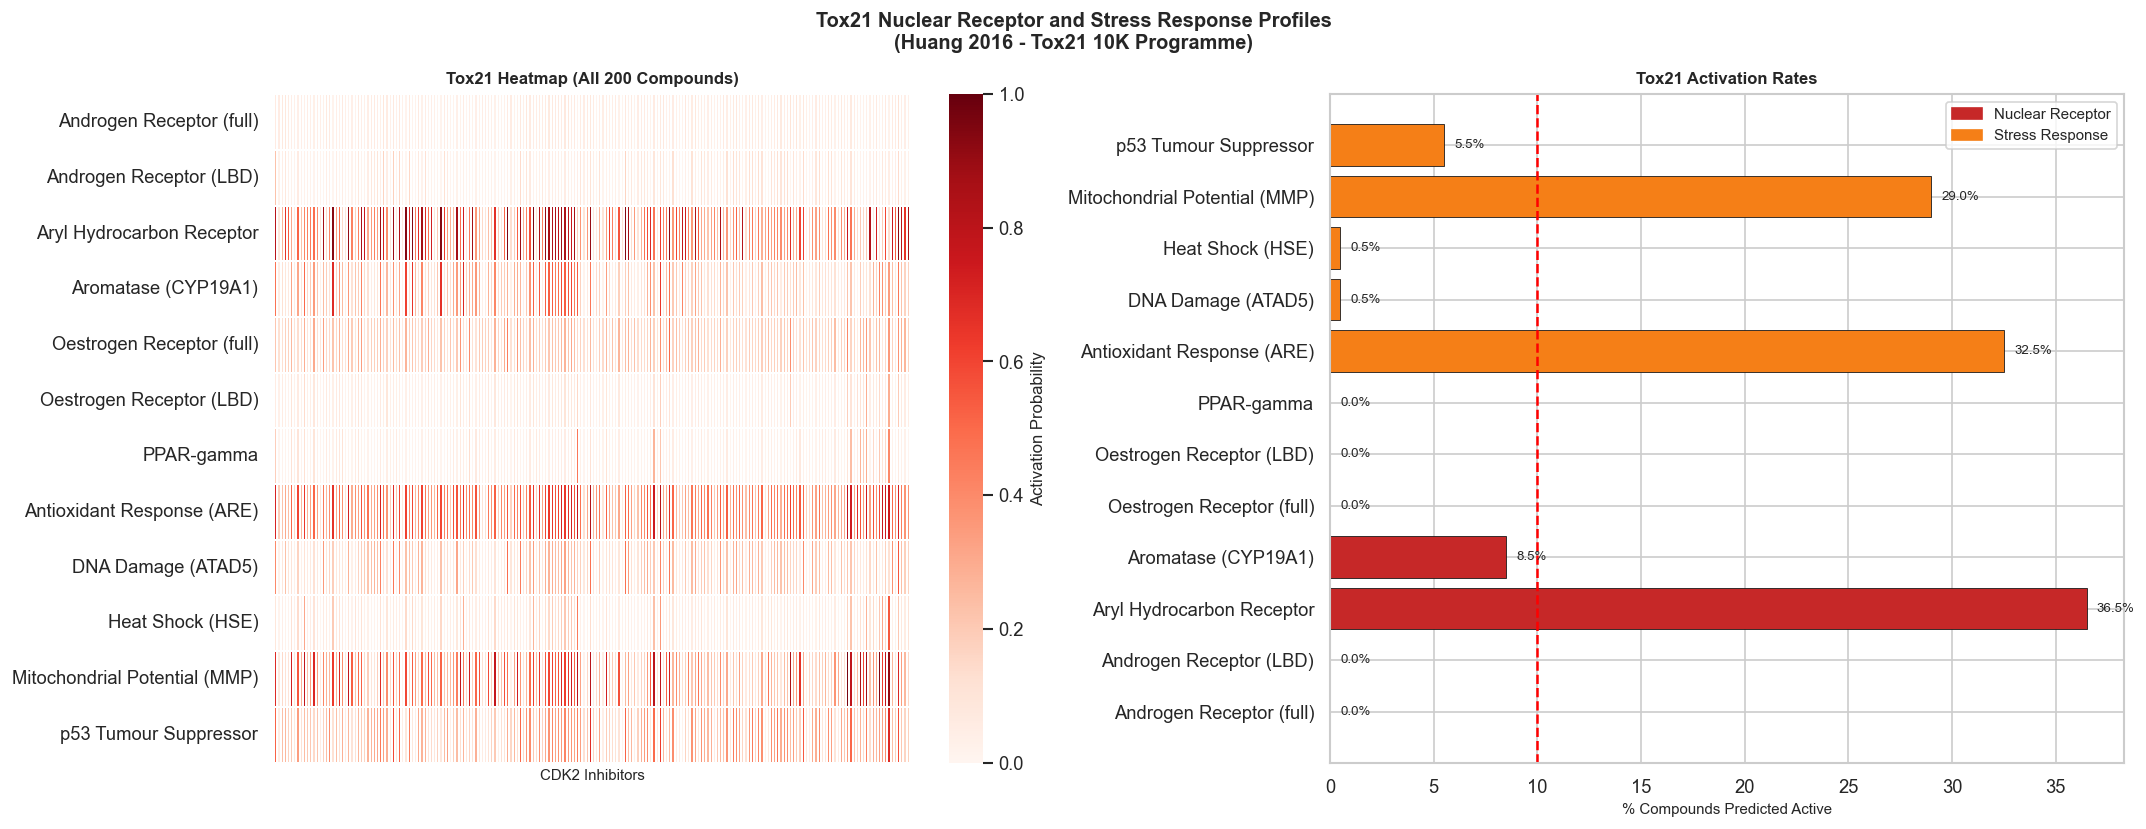

[SAVED] admet_tox21.png


In [12]:
# ============================================================
# CELL 10 - Tox21 nuclear receptor and stress response profiling
# Reference: Huang R et al. (2016) Nat Commun 7:10425
# doi:10.1038/ncomms10425
# ============================================================
tox21_nr = {'NR-AR':'Androgen Receptor (full)','NR-AR-LBD':'Androgen Receptor (LBD)',
            'NR-AhR':'Aryl Hydrocarbon Receptor','NR-Aromatase':'Aromatase (CYP19A1)',
            'NR-ER':'Oestrogen Receptor (full)','NR-ER-LBD':'Oestrogen Receptor (LBD)',
            'NR-PPAR-gamma':'PPAR-gamma'}
tox21_sr  = {'SR-ARE':'Antioxidant Response (ARE)','SR-ATAD5':'DNA Damage (ATAD5)',
             'SR-HSE':'Heat Shock (HSE)','SR-MMP':'Mitochondrial Potential (MMP)',
             'SR-p53':'p53 Tumour Suppressor'}
all_tox21 = list(tox21_nr.keys()) + list(tox21_sr.keys())
n = len(df_admet)

print('Tox21 Nuclear Receptor Activation')
print('='*60)
for col,label in tox21_nr.items():
    d      = df_admet[col].dropna()
    active = (d>=0.5).sum()
    print(f'  {label:<35}: {active}/{len(d)} ({100*active/len(d):.1f}%) active')

print('\nTox21 Stress Response Activation')
print('='*60)
for col,label in tox21_sr.items():
    d      = df_admet[col].dropna()
    active = (d>=0.5).sum()
    print(f'  {label:<35}: {active}/{len(d)} ({100*active/len(d):.1f}%) active')

tox21_flags = pd.DataFrame({col:(df_admet[col].fillna(0)>=0.5).astype(int) for col in all_tox21})
tox21_clean = (tox21_flags.sum(axis=1)==0).sum()
print(f'\nCompounds with ZERO Tox21 flags: {tox21_clean}/{n} ({100*tox21_clean/n:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Tox21 Nuclear Receptor and Stress Response Profiles\n(Huang 2016 - Tox21 10K Programme)',
             fontsize=12, fontweight='bold')

all_tox21_data = df_admet[all_tox21].fillna(0)
import seaborn as sns
sns.heatmap(all_tox21_data.T, ax=axes[0], cmap='Reds', vmin=0, vmax=1,
            yticklabels=list(tox21_nr.values())+list(tox21_sr.values()),
            xticklabels=False, linewidths=0.05, linecolor='white',
            cbar_kws={'label':'Activation Probability'})
axes[0].set_title('Tox21 Heatmap (All 200 Compounds)',fontsize=10)
axes[0].set_xlabel('CDK2 Inhibitors',fontsize=9)

all_labels  = list(tox21_nr.values())+list(tox21_sr.values())
pct_active  = [100*(df_admet[col].dropna()>=0.5).mean() for col in all_tox21]
bar_colors  = [PALETTE['risk']]*len(tox21_nr)+[PALETTE['moderate']]*len(tox21_sr)
bars = axes[1].barh(all_labels,pct_active,color=bar_colors,edgecolor='k',linewidth=0.5)
axes[1].axvline(10,color='red',linestyle='--',lw=1.5,label='10% concern threshold')
for bar,pct in zip(bars,pct_active):
    axes[1].text(pct+0.5,bar.get_y()+bar.get_height()/2,f'{pct:.1f}%',va='center',fontsize=8)
nr_p = mpatches.Patch(color=PALETTE['risk'],label='Nuclear Receptor')
sr_p = mpatches.Patch(color=PALETTE['moderate'],label='Stress Response')
axes[1].set_xlabel('% Compounds Predicted Active',fontsize=9)
axes[1].set_title('Tox21 Activation Rates',fontsize=10)
axes[1].legend(handles=[nr_p,sr_p],fontsize=9)

plt.tight_layout()
plt.savefig('admet_tox21.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_tox21.png')

## Cell 11 - DrugBank Approved Drug Percentile Ranking Analysis

A unique feature of ADMET-AI 2.0 is automatic comparison of each compound against 2,579
FDA-approved drugs from DrugBank [Wishart DS et al. (2018) Nucleic Acids Res 46(D1):D1074-D1082.
doi:10.1093/nar/gkx1037].

**Interpretation guide:**
- BBB_percentile = 75 means better BBB penetration than 75% of approved drugs
- hERG_percentile = 30 means lower hERG risk than only 30% of approved drugs (HIGH RISK)
- For favourable properties (absorption): **higher percentile = better**
- For unfavourable properties (toxicity): **lower percentile = lower risk = better**

DrugBank Percentile Rankings (vs 2,579 FDA-approved drugs)
  Property                             Mean%ile   Med%ile Interpretation
  ----------------------------------------------------------------------
  QED (drug-likeness)                      58.4      55.8   Better than avg drug
  BBB Penetration                          40.7      40.8   Below avg drug
  HIA (absorption)                         55.1      48.7   Better than avg drug
  Oral Bioavailability                     69.0      70.2   Better than avg drug
  CYP3A4 Inhibition                        76.1      78.6   Higher risk than avg
  hERG Inhibition                          74.4      78.2   Higher risk than avg
  AMES Mutagenicity                        65.2      70.5   Higher risk than avg
  DILI Risk                                83.5      83.1   Higher risk than avg
  Half-Life                                76.1      79.0   Better than avg drug
  Aqueous Solubility                       24.6      23.9   Below avg dr

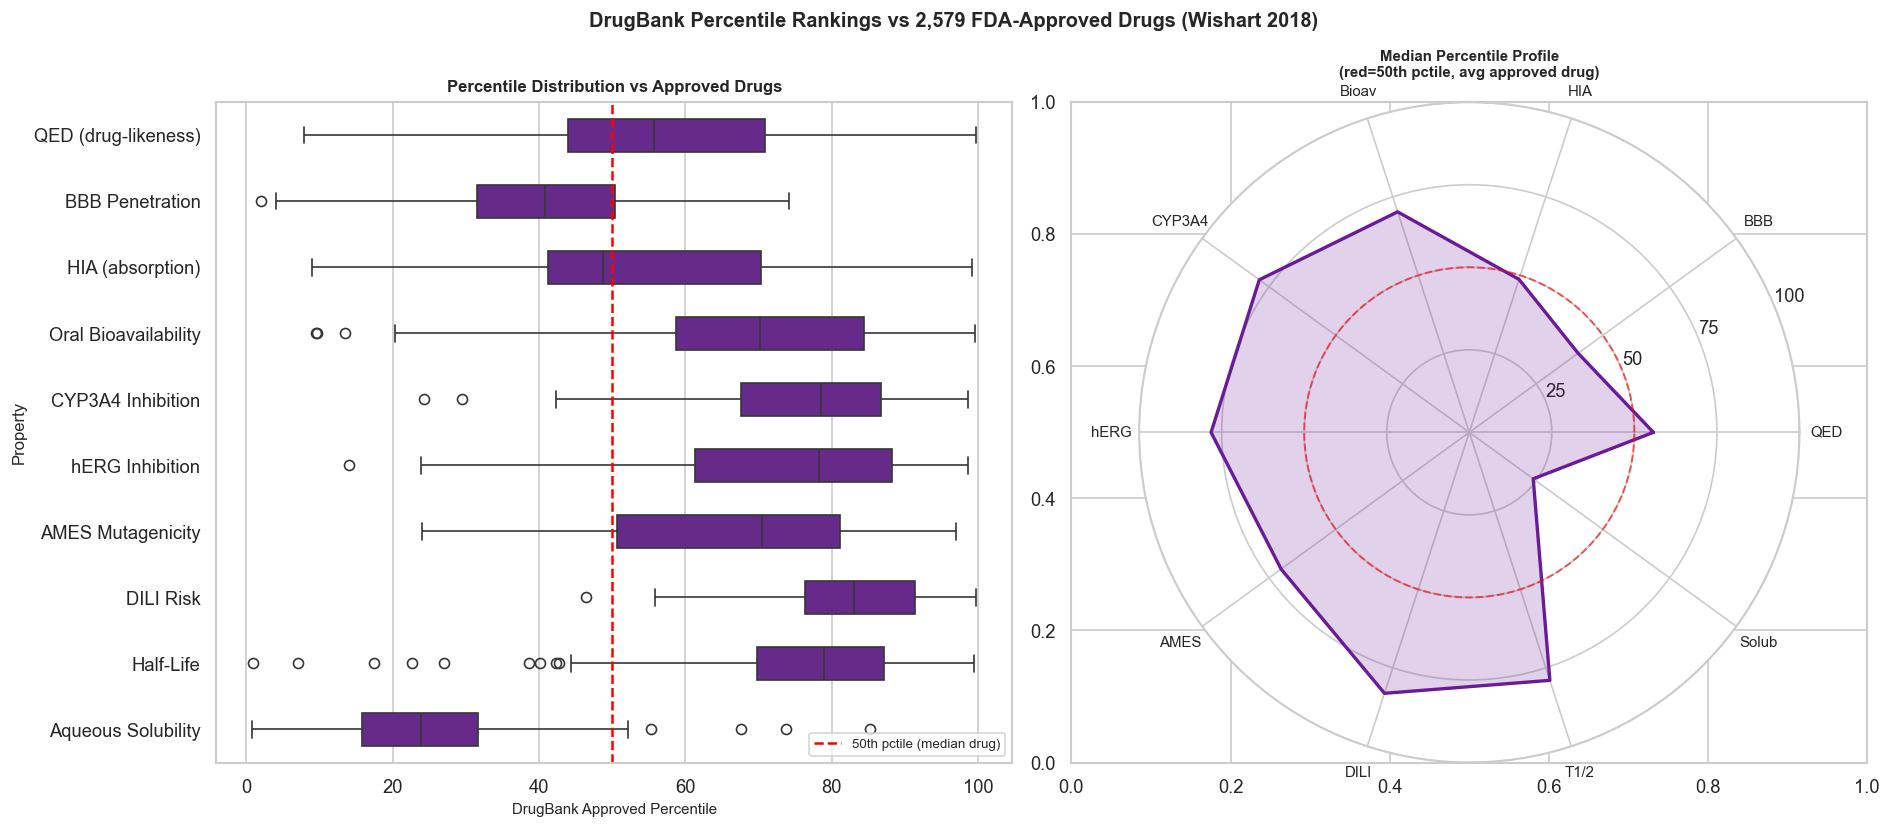

[SAVED] admet_drugbank_percentiles.png


In [13]:
# ============================================================
# CELL 11 - DrugBank percentile ranking analysis
# Reference: Wishart DS et al. (2018) Nucleic Acids Res 46(D1):D1074-D1082
# doi:10.1093/nar/gkx1037
# ============================================================
pct_interest = [
    ('QED_drugbank_approved_percentile','QED (drug-likeness)','high'),
    ('BBB_Martins_drugbank_approved_percentile','BBB Penetration','high'),
    ('HIA_Hou_drugbank_approved_percentile','HIA (absorption)','high'),
    ('Bioavailability_Ma_drugbank_approved_percentile','Oral Bioavailability','high'),
    ('CYP3A4_Veith_drugbank_approved_percentile','CYP3A4 Inhibition','low'),
    ('hERG_drugbank_approved_percentile','hERG Inhibition','low'),
    ('AMES_drugbank_approved_percentile','AMES Mutagenicity','low'),
    ('DILI_drugbank_approved_percentile','DILI Risk','low'),
    ('Half_Life_Obach_drugbank_approved_percentile','Half-Life','high'),
    ('Solubility_AqSolDB_drugbank_approved_percentile','Aqueous Solubility','high'),
]

print('DrugBank Percentile Rankings (vs 2,579 FDA-approved drugs)')
print('='*70)
print(f'  {"Property":<35} {"Mean%ile":>9} {"Med%ile":>9} {"Interpretation"}')
print('  '+'-'*70)
for col,label,direction in pct_interest:
    d = df_admet[col].dropna()
    if direction=='high':
        interp = 'Better than avg drug' if d.mean()>50 else 'Below avg drug'
    else:
        interp = 'Lower risk than avg' if d.mean()<50 else 'Higher risk than avg'
    print(f'  {label:<35} {d.mean():>9.1f} {d.median():>9.1f}   {interp}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('DrugBank Percentile Rankings vs 2,579 FDA-Approved Drugs (Wishart 2018)',
             fontsize=12, fontweight='bold')

# Box plots
pct_dict  = {label: df_admet[col].dropna().values for col,label,_ in pct_interest if len(df_admet[col].dropna())>0}
pct_df    = pd.DataFrame(dict(list(pct_dict.items())[:10]))
pct_long  = pct_df.melt(var_name='Property',value_name='Percentile')
sns.boxplot(data=pct_long, x='Percentile', y='Property', color=PALETTE['drugbank'], ax=ax1, width=0.5)
ax1.axvline(50, color='red', linestyle='--', lw=1.5, label='50th pctile (median drug)')
ax1.set_xlabel('DrugBank Approved Percentile',fontsize=9)
ax1.set_title('Percentile Distribution vs Approved Drugs',fontsize=10)
ax1.legend(fontsize=8)

# Radar chart
import numpy as np
median_vals  = [df_admet[col].dropna().median() for col,_,_ in pct_interest]
N            = len(pct_interest)
angles       = [n/float(N)*2*np.pi for n in range(N)]
angles      += angles[:1]
vals         = median_vals + [median_vals[0]]
short_labels = ['QED','BBB','HIA','Bioav','CYP3A4','hERG','AMES','DILI','T1/2','Solub']

ax2 = fig.add_subplot(1, 2, 2, polar=True)
ax2.plot(angles, vals, color=PALETTE['drugbank'], linewidth=2)
ax2.fill(angles, vals, color=PALETTE['drugbank'], alpha=0.2)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(short_labels, size=9)
ax2.set_ylim(0, 100)
ax2.set_yticks([25,50,75,100])
ax2.axhline(50, color='red', linestyle='--', lw=1.2, alpha=0.6)
ax2.set_title('Median Percentile Profile\n(red=50th pctile, avg approved drug)', fontsize=9, pad=15)

plt.tight_layout()
plt.savefig('admet_drugbank_percentiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_drugbank_percentiles.png')

## Cell 12 - ADMET Traffic Light Dashboard

The traffic light system colour-codes ADMET predictions as Green (favourable) or Red (risk)
for rapid compound prioritisation in drug discovery. This framework was formalised by
Gleeson MP et al. (2011) J Med Chem 54(15):5516-5523. doi:10.1021/jm200368p

| Property | Green (favourable) | Red (risk) |
|----------|-------------------|------------|
| hERG | Prob < 0.5 | Prob >= 0.5 |
| AMES | Prob < 0.5 | Prob >= 0.5 |
| DILI | Prob < 0.5 | Prob >= 0.5 |
| ClinTox | Prob < 0.5 | Prob >= 0.5 |
| BBB | Prob >= 0.5 | Prob < 0.5 |
| HIA | Prob >= 0.5 | Prob < 0.5 |
| Bioavailability | Prob >= 0.5 | Prob < 0.5 |
| Pgp | Prob < 0.5 | Prob >= 0.5 |
| Lipinski | >= 0.5 | < 0.5 |
| PAINS | Prob < 0.5 | Prob >= 0.5 |

ADMET Traffic Light Summary
  Properties assessed          : 13
  Mean green flags per compound: 9.5/13
  Compounds >= 10 green flags  : 94
  Compounds >= 12 green flags  : 25
  Compounds all 13 green       : 0


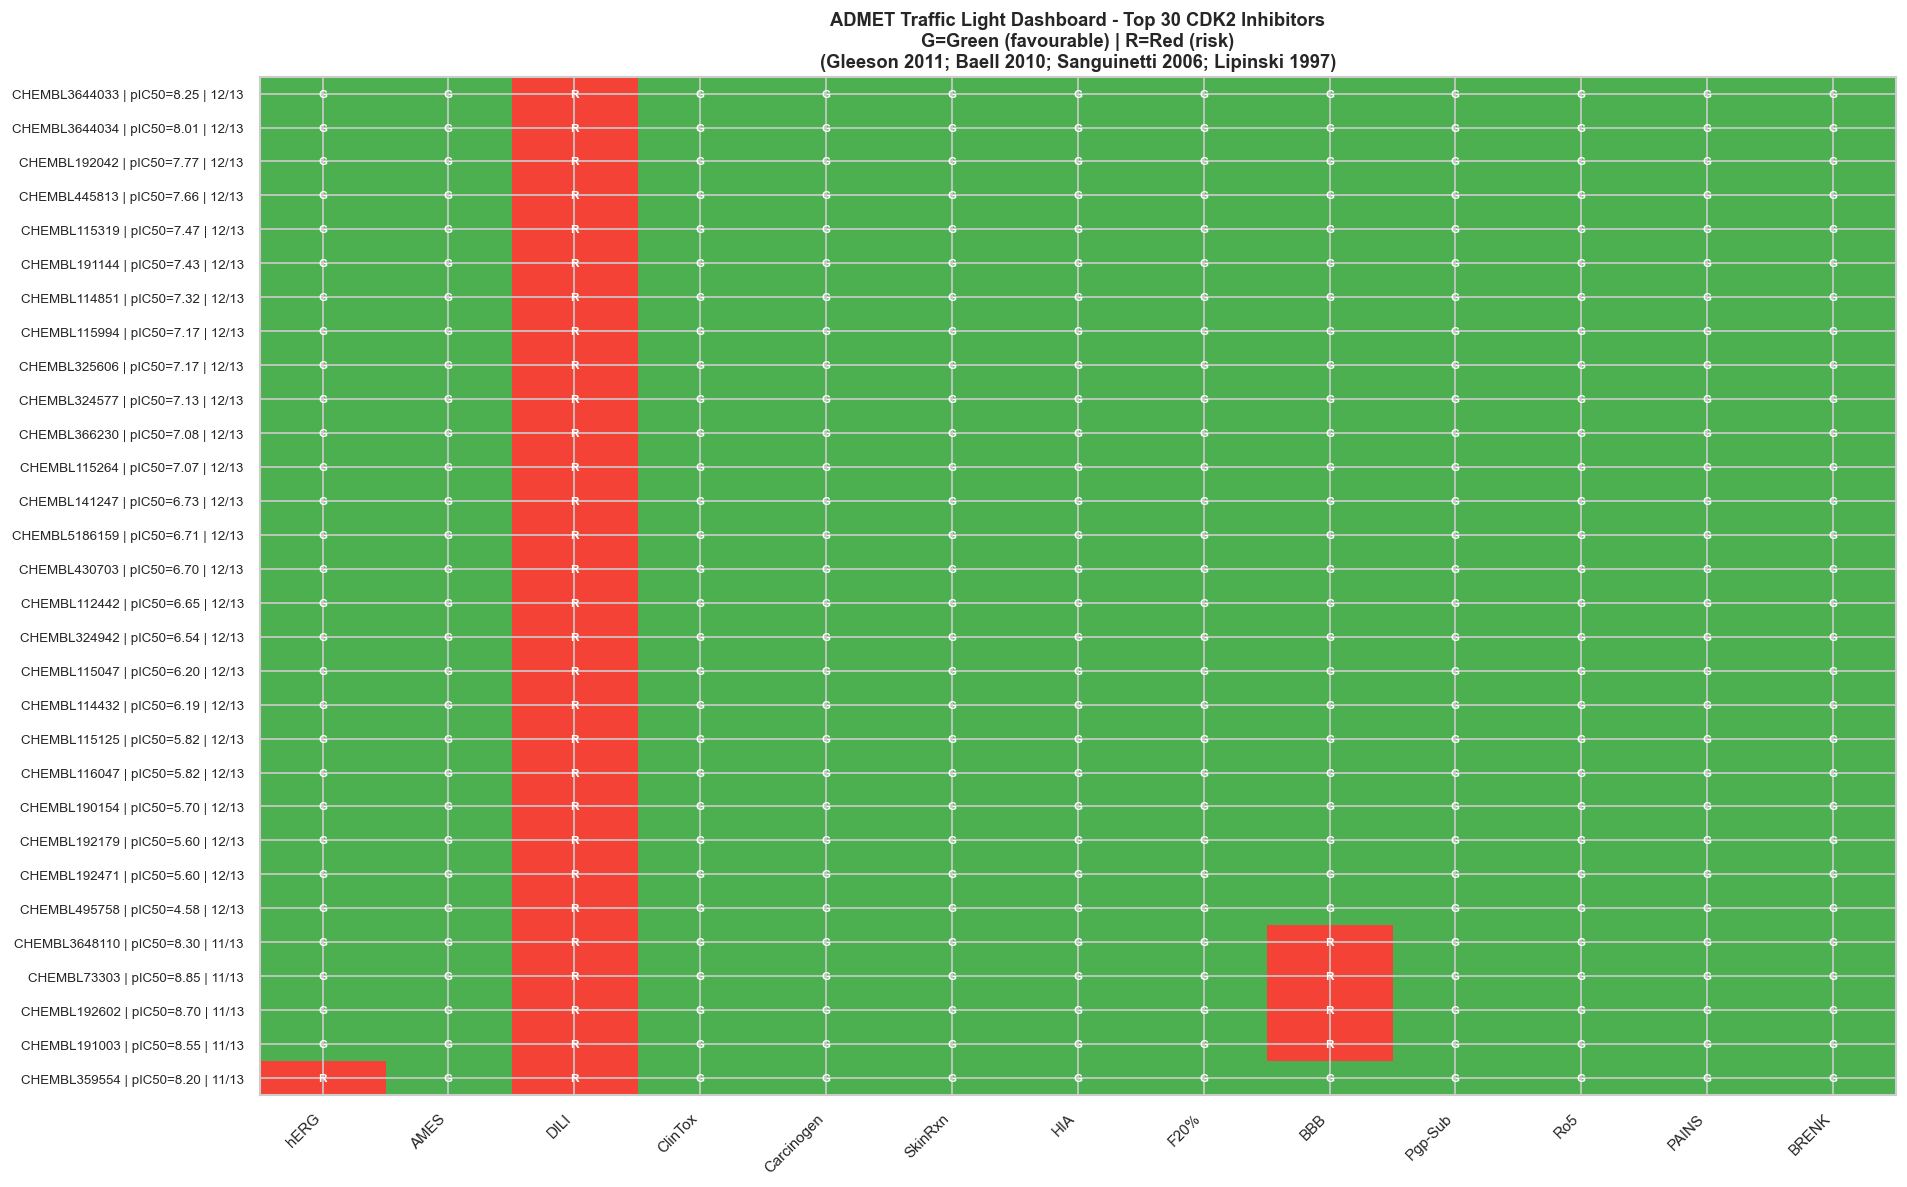

[SAVED] admet_traffic_light.png


In [14]:
# ============================================================
# CELL 12 - ADMET traffic light dashboard
# Reference: Gleeson MP et al. (2011) J Med Chem 54(15):5516-5523
# doi:10.1021/jm200368p
# ============================================================
from matplotlib.colors import LinearSegmentedColormap

tl_rules = [
    ('hERG',             0.5, 'low',  'hERG'),
    ('AMES',             0.5, 'low',  'AMES'),
    ('DILI',             0.5, 'low',  'DILI'),
    ('ClinTox',          0.5, 'low',  'ClinTox'),
    ('Carcinogens_Lagunin',0.5,'low', 'Carcinogen'),
    ('Skin_Reaction',    0.5, 'low',  'SkinRxn'),
    ('HIA_Hou',          0.5, 'high', 'HIA'),
    ('Bioavailability_Ma',0.5,'high', 'F20%'),
    ('BBB_Martins',      0.5, 'high', 'BBB'),
    ('Pgp_Broccatelli',  0.5, 'low',  'Pgp-Sub'),
    ('Lipinski',         0.5, 'high', 'Ro5'),
    ('PAINS_alert',      0.5, 'low',  'PAINS'),
    ('BRENK_alert',      0.5, 'low',  'BRENK'),
]

tl_data = {}
for col,thresh,direction,label in tl_rules:
    vals = df_admet[col].fillna(0.5)
    tl_data[label] = ((vals>=thresh) if direction=='high' else (vals<thresh)).astype(int)

tl_df = pd.DataFrame(tl_data)
tl_df['chembl_id']   = df_admet['chembl_id'].values
tl_df['pIC50']       = df_admet['pIC50'].values
tl_df['activity']    = df_admet['activity'].values
tl_df['green_count'] = tl_df[list(tl_data.keys())].sum(axis=1)

total = len(tl_df)
print('ADMET Traffic Light Summary')
print('='*55)
print(f'  Properties assessed          : {len(tl_rules)}')
print(f'  Mean green flags per compound: {tl_df["green_count"].mean():.1f}/{len(tl_rules)}')
print(f'  Compounds >= 10 green flags  : {(tl_df["green_count"]>=10).sum()}')
print(f'  Compounds >= 12 green flags  : {(tl_df["green_count"]>=12).sum()}')
print(f'  Compounds all 13 green       : {(tl_df["green_count"]==len(tl_rules)).sum()}')

top30      = tl_df.nlargest(30,'green_count').reset_index(drop=True)
tl_matrix  = top30[list(tl_data.keys())].values
green_red  = LinearSegmentedColormap.from_list('tl',['#F44336','#4CAF50'],N=2)

fig, ax = plt.subplots(figsize=(16, 10))
ax.imshow(tl_matrix, cmap=green_red, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(tl_data)))
ax.set_xticklabels(list(tl_data.keys()), rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(
    [f"{row['chembl_id']} | pIC50={row['pIC50']:.2f} | {row['green_count']}/13"
     for _,row in top30.iterrows()], fontsize=8)
for i in range(tl_matrix.shape[0]):
    for j in range(tl_matrix.shape[1]):
        ax.text(j,i,'G' if tl_matrix[i,j]==1 else 'R',
                ha='center',va='center',fontsize=7,fontweight='bold',color='white')
ax.set_title('ADMET Traffic Light Dashboard - Top 30 CDK2 Inhibitors\n'
             'G=Green (favourable) | R=Red (risk)\n'
             '(Gleeson 2011; Baell 2010; Sanguinetti 2006; Lipinski 1997)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('admet_traffic_light.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_traffic_light.png')

## Cell 13 - Composite ADMET Score and Compound Ranking

A composite ADMET score integrates all predicted endpoints into a single number representing
the overall safety and drug-likeness profile. This approach follows the Multi-Parameter
Optimisation (MPO) framework [Wager TT et al. (2010) ACS Chem Neurosci 1(6):435-449.
doi:10.1021/cn100008c] and the QED concept [Bickerton GR et al. (2012) Nat Chem 4:90-98].

**Weighting scheme (total = 1.0):**
- hERG, AMES, DILI, ClinTox: 0.15 each (60% total - toxicity dominates)
- HIA, Bioavailability, Caco-2: 0.08 each (24% total - absorption)
- Lipinski, QED: 0.05 each (10% total - drug-likeness)
- PAINS, BRENK: 0.03 each (6% total - structural alerts)

Composite ADMET Score Distribution
  Mean   : 0.4604
  Median : 0.4265
  Std    : 0.1121
  Range  : [0.2986, 0.7224]

  Excellent   :    0 (0.0%)
  Good        :   17 (8.5%)
  Moderate    :   54 (27.0%)
  Poor        :  129 (64.5%)

Top 10 by ADMET score:
    chembl_id  pIC50     activity     MW  logP  ADMET_score ADMET_tier
 CHEMBL115125  5.824 Intermediate 201.23 1.970       0.7224       Good
 CHEMBL112442  6.650       Active 193.25 2.026       0.7110       Good
 CHEMBL115047  6.201       Active 294.15 2.987       0.7023       Good
 CHEMBL191834  7.699       Active 340.38 2.986       0.6907       Good
 CHEMBL324186  6.783       Active 271.28 2.238       0.6900       Good
CHEMBL5589612  6.044       Active 348.35 1.550       0.6862       Good
CHEMBL1332616  4.613     Inactive 835.90 6.084       0.6766       Good
 CHEMBL192602  8.699       Active 339.40 2.559       0.6739       Good
 CHEMBL192179  5.602 Intermediate 340.38 2.986       0.6728       Good
 CHEMBL190154  5.699 Intermediate 

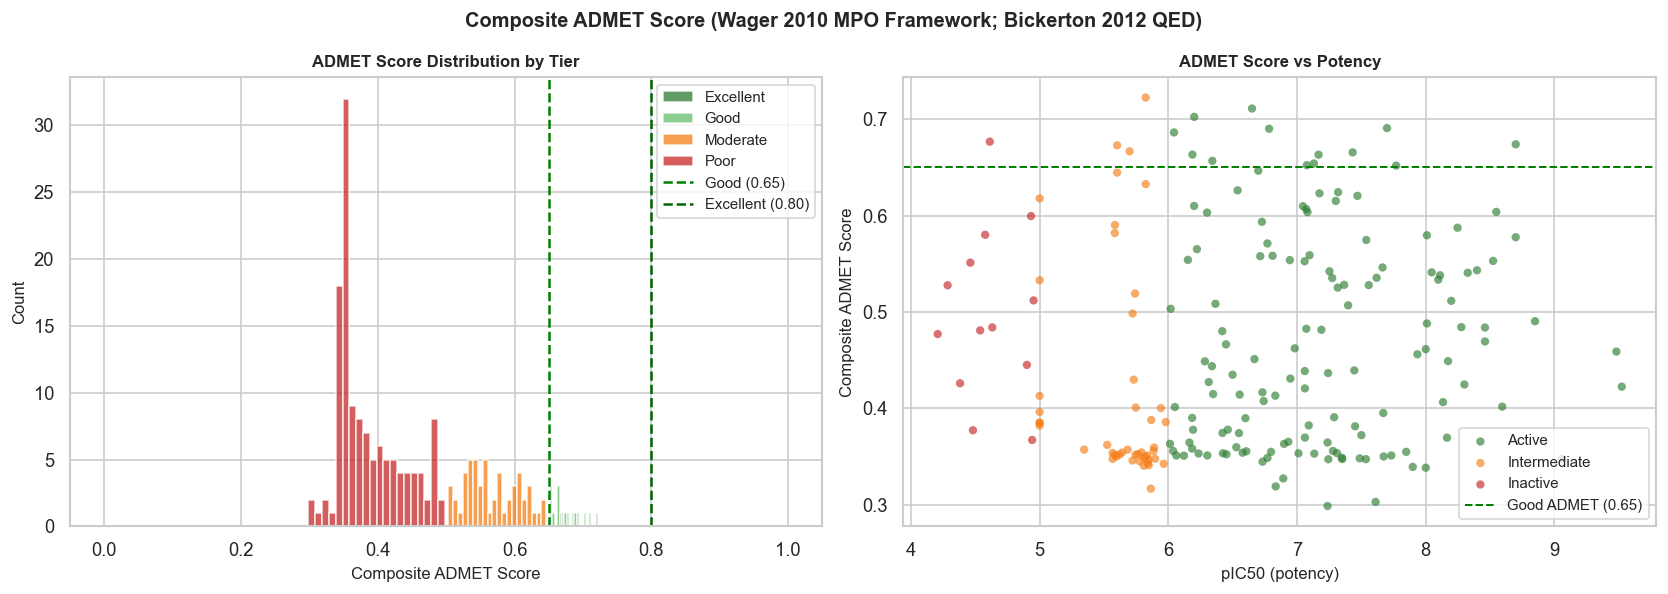

[SAVED] admet_composite_score.png


In [15]:
# ============================================================
# CELL 13 - Composite ADMET score
# Reference: Wager TT et al. (2010) ACS Chem Neurosci 1(6):435-449
# doi:10.1021/cn100008c
# ============================================================
def desr_low(val, thresh=0.5):
    """Low probability = safe (hERG, AMES, DILI) - Gleeson 2011"""
    return float(1 - min(max(float(val)/thresh, 0), 1))

def desr_high(val, thresh=0.5):
    """High probability = favourable (HIA, BBB) - Wager 2010"""
    return float(min(max(float(val)/thresh, 0), 1))

def desr_cont(val, low, high, higher_better=True):
    """Linear ramp for continuous endpoints"""
    if higher_better:
        return float(min(max((float(val)-low)/(high-low), 0), 1))
    return float(min(max((high-float(val))/(high-low), 0), 1))

weights = {
    'hERG':0.15,'AMES':0.15,'DILI':0.15,'ClinTox':0.15,
    'HIA_Hou':0.08,'Bioavailability_Ma':0.08,'Caco2_Wang':0.08,
    'Lipinski':0.05,'QED':0.05,
    'PAINS_alert':0.03,'BRENK_alert':0.03,
}

scores = []
for _, row in df_admet.iterrows():
    s  = weights['hERG']  * desr_low(row.get('hERG', 0.5))
    s += weights['AMES']  * desr_low(row.get('AMES', 0.5))
    s += weights['DILI']  * desr_low(row.get('DILI', 0.5))
    s += weights['ClinTox'] * desr_low(row.get('ClinTox', 0.5))
    s += weights['HIA_Hou'] * desr_high(row.get('HIA_Hou', 0.5))
    s += weights['Bioavailability_Ma'] * desr_high(row.get('Bioavailability_Ma', 0.5))
    s += weights['Caco2_Wang'] * desr_cont(row.get('Caco2_Wang',-6), -8, -4, True)
    s += weights['Lipinski']   * desr_high(row.get('Lipinski', 0.5))
    s += weights['QED'] * float(row.get('QED', 0.5))
    s += weights['PAINS_alert'] * desr_low(row.get('PAINS_alert', 0.5))
    s += weights['BRENK_alert'] * desr_low(row.get('BRENK_alert', 0.5))
    scores.append(round(s, 4))

df_admet['ADMET_score'] = scores
df_admet['ADMET_tier']  = df_admet['ADMET_score'].apply(
    lambda s: 'Excellent' if s>=0.80 else ('Good' if s>=0.65 else ('Moderate' if s>=0.50 else 'Poor')))

sc = df_admet['ADMET_score']
print('Composite ADMET Score Distribution')
print('='*50)
print(f'  Mean   : {sc.mean():.4f}')
print(f'  Median : {sc.median():.4f}')
print(f'  Std    : {sc.std():.4f}')
print(f'  Range  : [{sc.min():.4f}, {sc.max():.4f}]')
print()
for tier in ['Excellent','Good','Moderate','Poor']:
    n = (df_admet['ADMET_tier']==tier).sum()
    print(f'  {tier:<12}: {n:>4} ({100*n/len(df_admet):.1f}%)')

print('\nTop 10 by ADMET score:')
print(df_admet.nlargest(10,'ADMET_score')[['chembl_id','pIC50','activity','MW','logP','ADMET_score','ADMET_tier']].to_string(index=False))

tier_colors = {'Excellent':'#2E7D32','Good':'#66BB6A','Moderate':'#F57F17','Poor':'#C62828'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Composite ADMET Score (Wager 2010 MPO Framework; Bickerton 2012 QED)',
             fontsize=12, fontweight='bold')

for tier, col in tier_colors.items():
    sub = df_admet[df_admet['ADMET_tier']==tier]['ADMET_score']
    axes[0].hist(sub, bins=20, alpha=0.75, color=col, label=tier, edgecolor='white')
axes[0].axvline(0.65, color='green', linestyle='--', lw=1.5, label='Good (0.65)')
axes[0].axvline(0.80, color='darkgreen', linestyle='--', lw=1.5, label='Excellent (0.80)')
axes[0].set_xlabel('Composite ADMET Score',fontsize=10)
axes[0].set_ylabel('Count',fontsize=10)
axes[0].set_title('ADMET Score Distribution by Tier',fontsize=10)
axes[0].legend(fontsize=9)

for cls,clr in act_colors.items():
    sub = df_admet[df_admet['activity']==cls]
    axes[1].scatter(sub['pIC50'], sub['ADMET_score'], c=clr, label=cls, alpha=0.65, s=25, edgecolors='none')
axes[1].axhline(0.65, color='green', linestyle='--', lw=1.2, label='Good ADMET (0.65)')
axes[1].set_xlabel('pIC50 (potency)',fontsize=10)
axes[1].set_ylabel('Composite ADMET Score',fontsize=10)
axes[1].set_title('ADMET Score vs Potency',fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('admet_composite_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] admet_composite_score.png')

## Cell 14 - 2D Structure Grid: Top Compounds by ADMET Score

The twelve CDK2 inhibitors with the highest composite ADMET scores are rendered as a
2D structure grid using RDKit's Cairo-free MolDraw2DSVG renderer. Each structure is
annotated with pIC50, ADMET score, and hERG probability.

The Cairo-free rendering approach avoids the RuntimeError that occurs when RDKit's
higher-level MolToImage() and MolsToGridImage() functions are called without Cairo
support compiled into the RDKit build [Landrum G (2006) RDKit: open-source cheminformatics].

[SAVED] 12 top ADMET structures: admet_top12_structures.svg


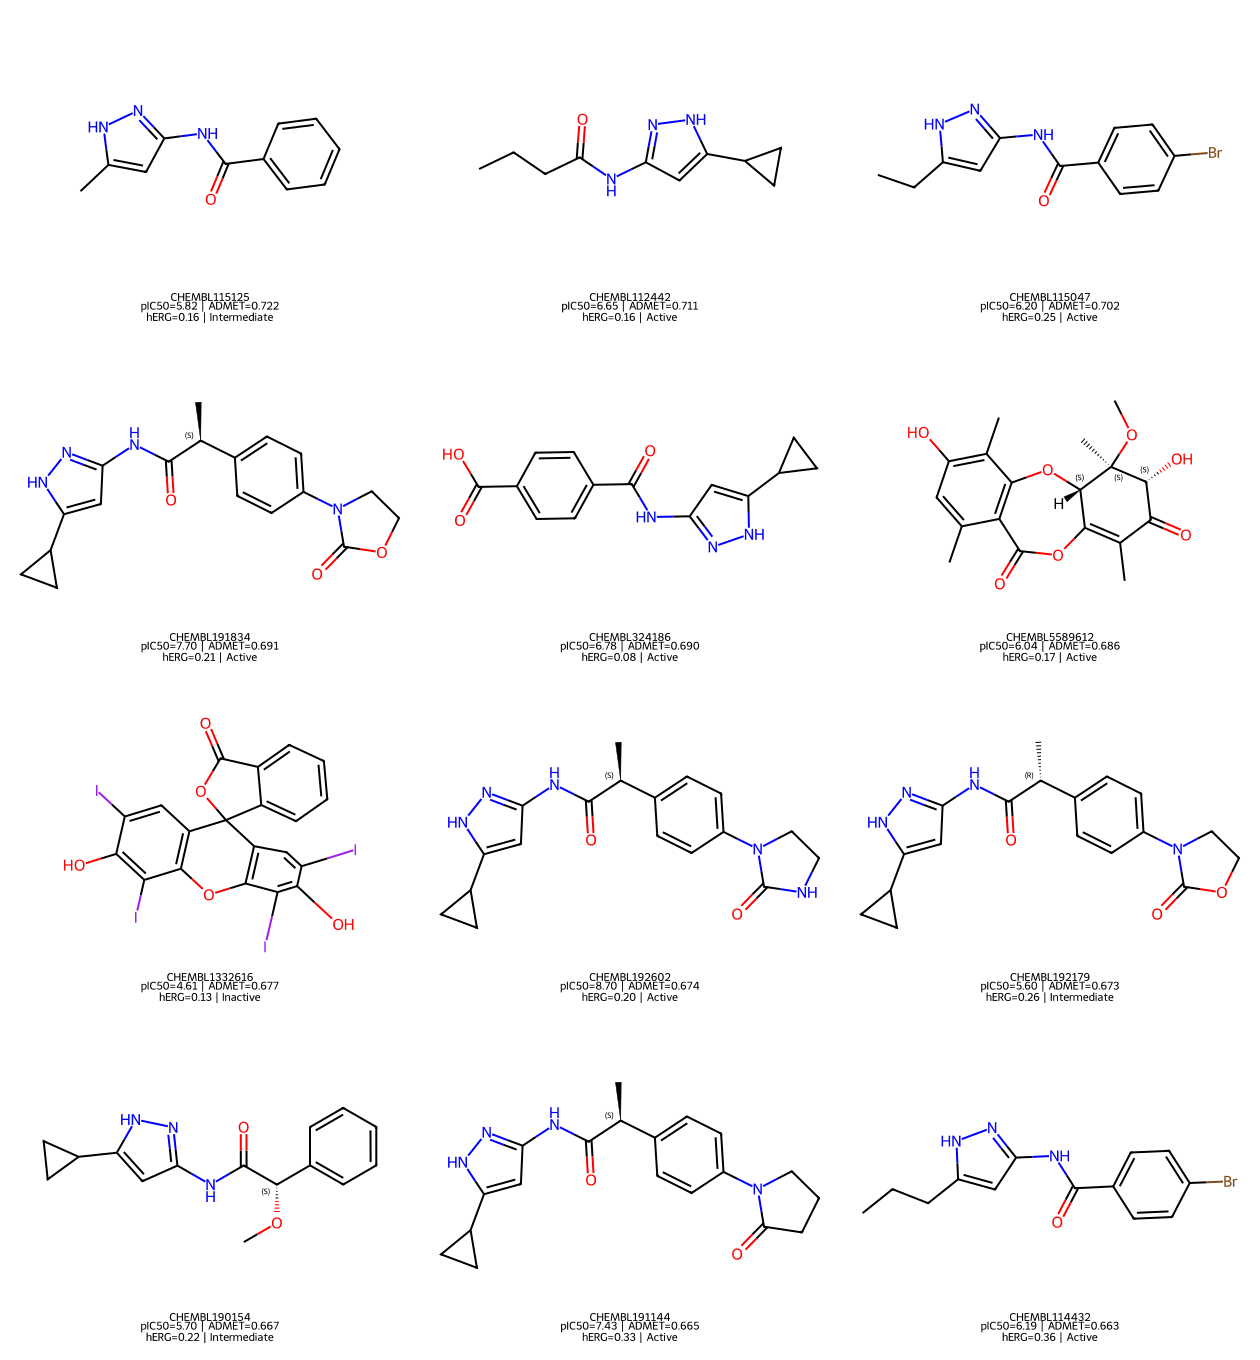

In [16]:
# ============================================================
# CELL 14 - 2D structure grid (Cairo-free SVG renderer)
# Reference: Landrum G (2006) RDKit open-source cheminformatics
# ============================================================
from IPython.display import SVG, display
from rdkit.Chem.Draw import rdMolDraw2D as rdd

top12 = df_admet.nlargest(12,'ADMET_score').copy()
top12 = top12[top12['mol'].notna()].head(12)

labels = []
for _, row in top12.iterrows():
    herg_vals = df_admet.loc[df_admet['chembl_id']==row['chembl_id'],'hERG'].values
    herg_str  = f"{herg_vals[0]:.2f}" if len(herg_vals)>0 and not pd.isna(herg_vals[0]) else 'N/A'
    labels.append(f"{row['chembl_id']}\npIC50={row['pIC50']:.2f} | ADMET={row['ADMET_score']:.3f}\nhERG={herg_str} | {row['activity']}")

mols   = top12['mol'].tolist()
n_cols = 3
n_rows = (len(mols)+n_cols-1)//n_cols
w, h   = 420, 340

canvas = rdMolDraw2D.MolDraw2DSVG(n_cols*w, n_rows*h, w, h)
canvas.drawOptions().addStereoAnnotation = True

prepared = []
for mol in mols:
    try:
        m = Chem.RWMol(mol)
        rdd.PrepareMolForDrawing(m)
        prepared.append(m)
    except:
        prepared.append(mol)

canvas.DrawMolecules(prepared, legends=labels)
canvas.FinishDrawing()
svg_str = canvas.GetDrawingText()

with open('admet_top12_structures.svg','w',encoding='utf-8') as f:
    f.write(svg_str)
print(f'[SAVED] {len(mols)} top ADMET structures: admet_top12_structures.svg')
display(SVG(svg_str))

## Cell 15 - Integrated ADMET Report Export

This cell exports a comprehensive CSV report containing all 200 CDK2 inhibitors with their
complete ADMET profiles across all 104 ADMET-AI properties plus the traffic light flags
and composite ADMET score.

This report follows FAIR data principles [Wilkinson MD et al. (2016) Sci Data 3:160018.
doi:10.1038/sdata.2016.18]: Findable (GitHub + Zenodo DOI), Accessible (MIT license),
Interoperable (standard CSV with ChEMBL IDs and SMILES), Reusable (complete documentation).

In [17]:
# ============================================================
# CELL 15 - Integrated ADMET report export
# Reference: Wilkinson MD et al. (2016) Sci Data 3:160018
# doi:10.1038/sdata.2016.18
# ============================================================

# Merge traffic light green_count
tl_merge = tl_df[['chembl_id','green_count']].copy()
final    = df_admet.merge(tl_merge, on='chembl_id', how='left', suffixes=('','_tl'))

# Select columns
base_cols = ['chembl_id','smiles','IC50_nM','pIC50','activity',
             'MW','logP','HBD','HBA','TPSA','HAC','RotBonds','Fsp3']
all_cols  = base_cols + RAW_COLS + PCT_COLS + ['green_count','ADMET_score','ADMET_tier']
avail     = [c for c in all_cols if c in final.columns]
report    = final[avail].drop_duplicates(subset='chembl_id')
report    = report.sort_values('ADMET_score', ascending=False).reset_index(drop=True)
report.to_csv('cdk2_integrated_admet_report.csv', index=False)

print('=' * 65)
print('  TUTORIAL 4: CDK2 ADMET PROFILING - Final Summary')
print('=' * 65)
print(f'  Target                     : CDK2 (CHEMBL301, Homo sapiens)')
print(f'  Compounds profiled         : {len(report)}')
print(f'  ADMET-AI version           : {admet_ai.__version__}')
print(f'  Endpoints predicted        : {len(RAW_COLS)} raw + {len(PCT_COLS)} percentile = {len(RAW_COLS)+len(PCT_COLS)}')
print(f'  Active (pIC50 >= 6.0)      : {(report["pIC50"]>=6).sum()}')
print()
for tier in ['Excellent','Good','Moderate','Poor']:
    n = (report['ADMET_tier']==tier).sum()
    print(f'  ADMET {tier:<12}: {n:>4} ({100*n/len(report):.1f}%)')
print()
print(f'  Mean ADMET score : {report["ADMET_score"].mean():.4f}')
print(f'  Report columns   : {len(avail)}')
print()
print('Output files generated:')
for fname in [
    'cdk2_admet_raw_predictions.csv',
    'admet_physicochemical.png',
    'admet_druglikeness_alerts.png',
    'admet_absorption.png',
    'admet_distribution.png',
    'admet_cyp450_metabolism.png',
    'admet_excretion.png',
    'admet_toxicity.png',
    'admet_tox21.png',
    'admet_drugbank_percentiles.png',
    'admet_traffic_light.png',
    'admet_composite_score.png',
    'admet_top12_structures.svg',
    'cdk2_integrated_admet_report.csv',
]:
    print(f'  [FILE] {fname}')
print()
print('[DONE] Tutorial 4 complete. All outputs ready for publication.')

  TUTORIAL 4: CDK2 ADMET PROFILING - Final Summary
  Target                     : CDK2 (CHEMBL301, Homo sapiens)
  Compounds profiled         : 200
  ADMET-AI version           : 2.0.1
  Endpoints predicted        : 52 raw + 52 percentile = 104
  Active (pIC50 >= 6.0)      : 140

  ADMET Excellent   :    0 (0.0%)
  ADMET Good        :   17 (8.5%)
  ADMET Moderate    :   54 (27.0%)
  ADMET Poor        :  129 (64.5%)

  Mean ADMET score : 0.4604
  Report columns   : 119

Output files generated:
  [FILE] cdk2_admet_raw_predictions.csv
  [FILE] admet_physicochemical.png
  [FILE] admet_druglikeness_alerts.png
  [FILE] admet_absorption.png
  [FILE] admet_distribution.png
  [FILE] admet_cyp450_metabolism.png
  [FILE] admet_excretion.png
  [FILE] admet_toxicity.png
  [FILE] admet_tox21.png
  [FILE] admet_drugbank_percentiles.png
  [FILE] admet_traffic_light.png
  [FILE] admet_composite_score.png
  [FILE] admet_top12_structures.svg
  [FILE] cdk2_integrated_admet_report.csv

[DONE] Tutorial 4 co